In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

# **Случайные леса (Random Forests)**

## **Теория**

Ансамбль методов (ensemble), объединение несколько моделей машинного обучения (деревьев решений в данном случае)

Какие причины побудили создать рандомные леса? 

Дерево решений ограничены Gini impurity, - далеко не факт, что будут использованы все признаки. Теряем возможность извлечь инф-ию из всех признаков, ведь используются только самые важные признаки. 

Корневой признак очень сильно влияют на все дерево. В корневом узле находится тот признак, который лучше всего разбивает данные.

Нек-ым признакам дается либо слишком маленький, либо даже нулевой вес.

Даже после оптимизации дерева решений с п-ью гиперпараметров, оно имеет след.недостатки:

- Только один признак в корневом узле
- В разбиении могут участвовать не все признаки
- Возможное переобучение

Строим разбиение на случайных поднаборах признаков. Скорее всего, полученное дерево не будет переобучено

Деревья получают возм-ть стать глубже без риска переобучения

## **Bagging**

В случайных лесах мы используем выборки данных (**B**ootstrapped data) и далее делаем предсказания на основе агрегатных предсказаний деревьев(**AG**gregated prediction).
$$
B + AG = BAG
$$

- Для классификации: самый частый класс Y
- Для регрессии: среднее предсказание Y

**Bootstrapping** - берем только некоторые строки и столбцы из данных для каждого дерева.

Получается, что для некоторых деревьев некоторые данные остаются неиспользованными во время обучения. 
    
И если данных достаточно много, то статистически может случиться, что в конкретном дереве может НЕ участвовать достаочно большое кол-во данных, вплоть до 1/3 от всех данных.

*Пример*:

Из набора из 5 признаков (индексы 0 - 4) и 6 строк (индексы 0 - 5) для обучения конкретного дерева выпали строки [5, 1, 3, 5, 4] и признаки [2, 1, 4].

В Bootstrapping строки могут использованы более одного раза, за это отвечает параметр **bootstap samples** - использовать ли для построения поднаборы с *возвращением*?

Те строки, которые не поучаствовали в обучении конкретного дерева, можно использовать как тестовые для данного дерева.

Out of bag samples - так называются эти строки. На них можно вычислить метрики оценки модели для деревьев, и это будет ошибкой на тестовом наборе данных.

1) Подаем out of bag samples-строки на вход дереву
2) На выходе получаем предсказание модели ($y_{hat}$)
3) Сравниваем с истинными значениями
4) Вычисляем метрику ошибки - **Out of Bag Error (OOB Error)** !Данная метрика не является полноценной заменой метрике ошибки всего наблора данных!

Гиперпараметр OOB Score НЕ ВЛИЯЕТ на обучение модели, он сущ-т отдельно от bootstrapping, он нужен для опциональной оценки работы модели. 

Это альтернатива обычному train_test_split, поскольку bootstrapping сам по себе приводит к тому, что часть данных не участвует в процессе обучения

OOВ Score применяется только когда используются не все деревья в случайном лесу, поскольку эта метрика вычисляется только для деревьев, которые не использовали OOB.

Это значит, что для получения предсказания для конкретного объекта мы не можем использовать весь лес целиком. Мы используем только его подмножество (те деревья, для которых этот объект был «невиданным»).

## **Random Forest Classification. Код**

In [4]:
df = pd.read_csv(r"C:\Users\Надежда\Downloads\UNZIP_ME_FOR_NOTEBOOKS_ML_RUS_V14\DATA\penguins_size.csv")

In [5]:
df = df.dropna()

In [6]:
df.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE


In [7]:
X = pd.get_dummies(df.drop('species', axis=1), drop_first=True)

In [12]:
X.head()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,island_Dream,island_Torgersen,sex_FEMALE,sex_MALE
0,39.1,18.7,181.0,3750.0,False,True,False,True
1,39.5,17.4,186.0,3800.0,False,True,True,False
2,40.3,18.0,195.0,3250.0,False,True,True,False
4,36.7,19.3,193.0,3450.0,False,True,True,False
5,39.3,20.6,190.0,3650.0,False,True,False,True


In [9]:
y = df['species']

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

In [13]:
from sklearn.ensemble import RandomForestClassifier

Самая простая реализация, чтобы просто понять принцип работы RFC

In [15]:
rfc = RandomForestClassifier(n_estimators=10, max_features='sqrt', random_state=101)

In [16]:
rfc.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",10
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [17]:
preds = rfc.predict(X_test)

In [18]:
preds

array(['Chinstrap', 'Gentoo', 'Adelie', 'Chinstrap', 'Gentoo',
       'Chinstrap', 'Adelie', 'Gentoo', 'Chinstrap', 'Gentoo', 'Adelie',
       'Adelie', 'Adelie', 'Gentoo', 'Gentoo', 'Adelie', 'Gentoo',
       'Adelie', 'Adelie', 'Adelie', 'Gentoo', 'Chinstrap', 'Adelie',
       'Adelie', 'Adelie', 'Adelie', 'Chinstrap', 'Gentoo', 'Adelie',
       'Chinstrap', 'Gentoo', 'Chinstrap', 'Gentoo', 'Adelie', 'Adelie',
       'Chinstrap', 'Adelie', 'Gentoo', 'Chinstrap', 'Gentoo', 'Adelie',
       'Adelie', 'Gentoo', 'Adelie', 'Adelie', 'Chinstrap', 'Chinstrap',
       'Chinstrap', 'Chinstrap', 'Chinstrap', 'Adelie', 'Adelie',
       'Gentoo', 'Gentoo', 'Chinstrap', 'Adelie', 'Chinstrap',
       'Chinstrap', 'Gentoo', 'Adelie', 'Chinstrap', 'Gentoo', 'Adelie',
       'Adelie', 'Adelie', 'Gentoo', 'Chinstrap', 'Chinstrap', 'Gentoo',
       'Gentoo', 'Gentoo', 'Gentoo', 'Gentoo', 'Gentoo', 'Gentoo',
       'Gentoo', 'Gentoo', 'Gentoo', 'Adelie', 'Gentoo', 'Adelie',
       'Adelie', 'Gentoo', 'A

In [19]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

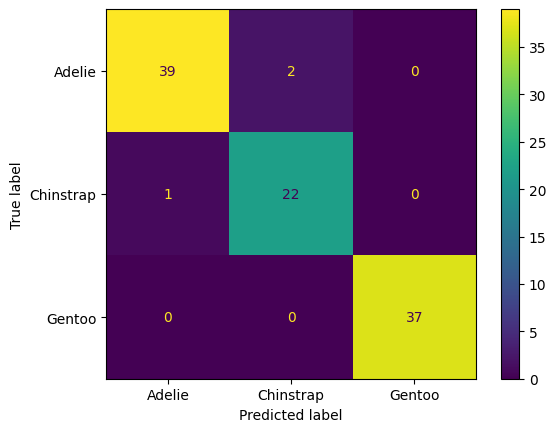

In [20]:
ConfusionMatrixDisplay.from_estimator(rfc, X_test, y_test)

In [21]:
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

      Adelie       0.97      0.95      0.96        41
   Chinstrap       0.92      0.96      0.94        23
      Gentoo       1.00      1.00      1.00        37

    accuracy                           0.97       101
   macro avg       0.96      0.97      0.97       101
weighted avg       0.97      0.97      0.97       101



Поработаем с более крупным набором данных, используем кросс-валидацию и поиск по сетке

In [32]:
df = pd.read_csv(r"C:\Users\Надежда\Downloads\UNZIP_ME_FOR_NOTEBOOKS_ML_RUS_V14\DATA\data_banknote_authentication.csv")

Target "Class":
 
Class 0 is "genuine"

Class 1 is "forgery"

In [33]:
df.head()

,Variance_Wavelet,Skewness_Wavelet,Curtosis_Wavelet,Image_Entropy,Class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [34]:
df.shape

(1372, 5)

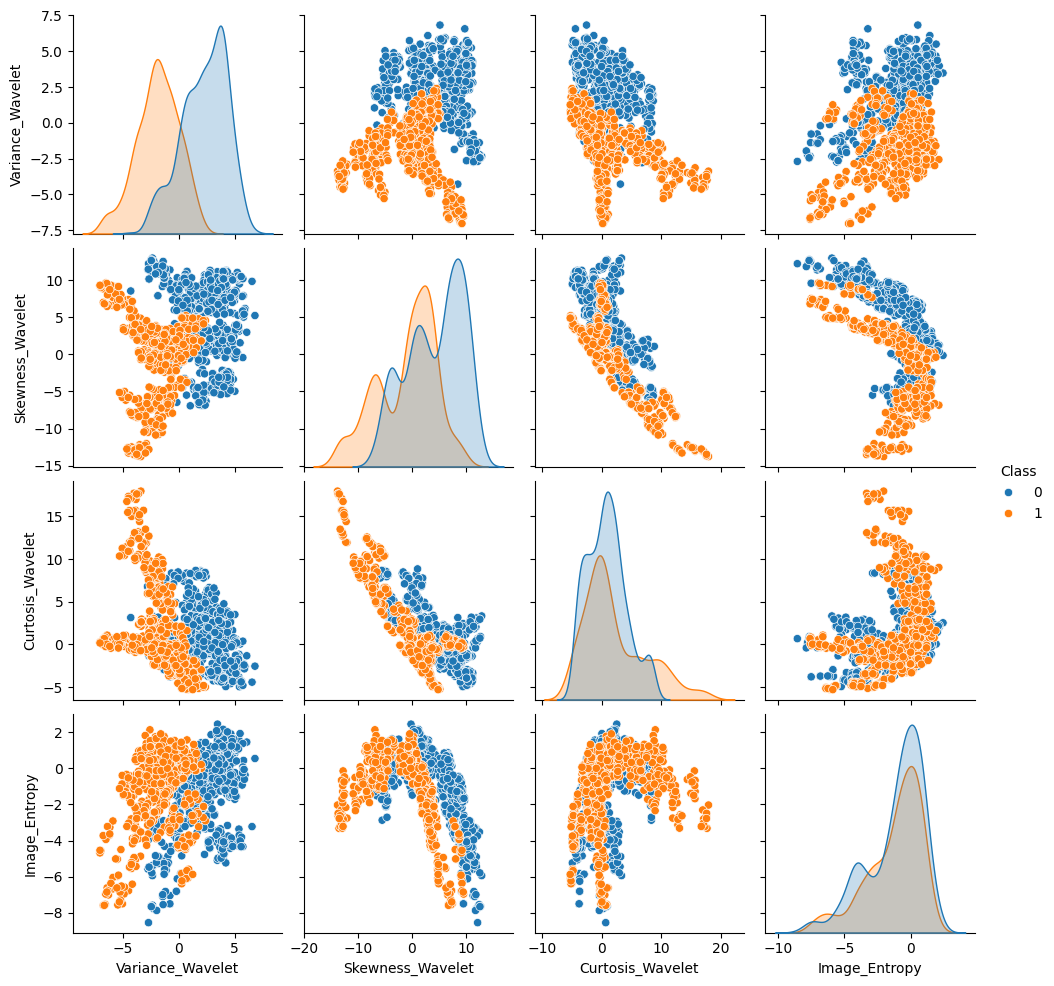

In [35]:
sns.pairplot(data=df, hue='Class')

In [36]:
df.isnull().sum()

Variance_Wavelet    0
Skewness_Wavelet    0
Curtosis_Wavelet    0
Image_Entropy       0
Class               0
dtype: int64

In [44]:
X = df.drop('Class', axis=1)
y=df['Class']

В каждом конкретном узле дерева мы работает с одним признаком, поэтому масштабирование можно не делать!

In [45]:
from sklearn.model_selection import train_test_split

Тестовый набор по сути будет hold-out test set из-за кросс-валидации и поиска по сетке. Поэтому сделаем его небольшим

In [46]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=101)


In [47]:
from sklearn.model_selection import GridSearchCV

In [48]:
from sklearn.ensemble import RandomForestClassifier

In [49]:
n_estimators = [64, 100, 128, 200]
max_features = [2, 3, 4]
bootstrap = [True, False]
oob_score = [True, False]

Комбинация bootstrap=False, oob_score=True смысла НЕ ИМЕЕТ. Вылезет предупреждение

In [55]:
param_grid = [
    {
        'n_estimators': n_estimators,
        'max_features': max_features,
        'bootstrap': [True],
        'oob_score': [True, False]
    },
    {
        'n_estimators': n_estimators,
        'max_features': max_features,
        'bootstrap': [False],
        'oob_score': [False]
    }
]

In [56]:
rfc = RandomForestClassifier()

In [57]:
grid = GridSearchCV(estimator=rfc, param_grid=param_grid)

In [58]:
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'bootstrap': [True], 'max_features': [2, 3, ...], 'n_estimators': [64, 100, ...], 'oob_score': [True, False]}, {'bootstrap': [False], 'max_features': [2, 3, ...], 'n_estimators': [64, 100, ...], 'oob_score': [False]}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the v

In [59]:
grid.best_params_

{'bootstrap': True, 'max_features': 2, 'n_estimators': 64, 'oob_score': True}

In [60]:
rfc_best = RandomForestClassifier(max_features=2, n_estimators=64, oob_score=True, bootstrap=True)

In [61]:
rfc_best.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",64
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",2
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_tru

In [63]:
rfc_best.oob_score_
#доля зн-ий, которые были вычислены правильно

0.9922813036020584

In [ ]:
more_rfc = 

In [64]:
preds = rfc_best.predict(X_test)

In [70]:
preds

array([0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1,
       1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0,
       1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 1, 1, 0, 1, 1, 0])

In [71]:
y_test

194     0
622     0
1063    1
390     0
327     0
       ..
897     1
354     0
1057    1
869     1
352     0
Name: Class, Length: 206, dtype: int64

In [73]:
np.sum(preds != y_test)

np.int64(2)

In [65]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

In [66]:
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99       124
           1       0.98      1.00      0.99        82

    accuracy                           0.99       206
   macro avg       0.99      0.99      0.99       206
weighted avg       0.99      0.99      0.99       206



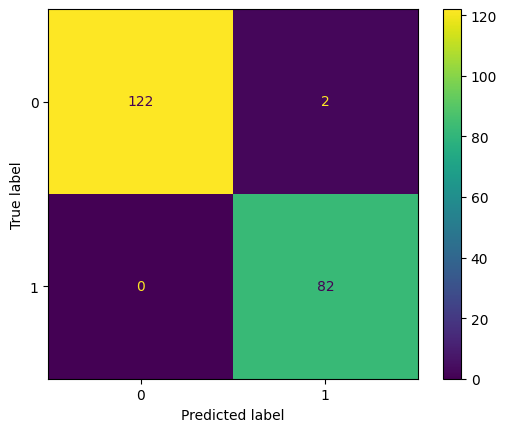

In [68]:
ConfusionMatrixDisplay.from_estimator(rfc_best, X_test, y_test)

In [69]:
from sklearn.metrics import accuracy_score

In [74]:
errors = []
misclassifications = []

for n in range(1, 200):

    rfc = RandomForestClassifier(n_estimators=n, max_features=2)
    rfc.fit(X_train, y_train)
    predictions = rfc.predict(X_test)
    err = 1 - accuracy_score(y_test, predictions)
    n_missed = np.sum(y_test != predictions)
    errors.append(err)
    misclassifications.append(n_missed)

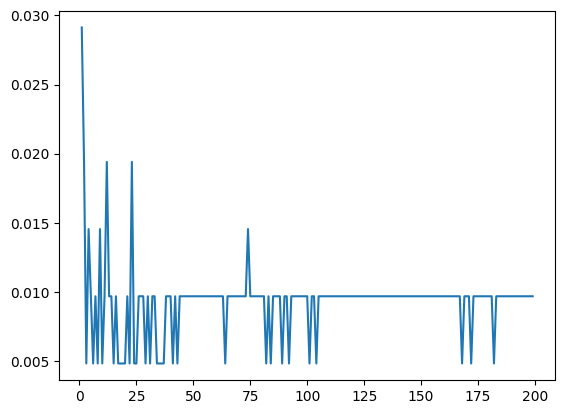

In [76]:
plt.plot(range(1,200), errors)

## **Random Forest Regression**

Данные выглядят в виде *синусоиды*, не все модели умеют с таким работать. Поэтому мы рассмотрим результаты работы многих видов моделей.

In [2]:
df = pd.read_csv(r"C:\Users\Надежда\Downloads\UNZIP_ME_FOR_NOTEBOOKS_ML_RUS_V14\DATA\rock_density_xray.csv")

In [3]:
df.shape

(300, 2)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 2 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Rebound Signal Strength nHz  300 non-null    float64
 1   Rock Density kg/m3           300 non-null    float64
dtypes: float64(2)
memory usage: 4.8 KB


In [6]:
df.describe()

,Rebound Signal Strength nHz,Rock Density kg/m3
count,300.000000,300.000000
mean,49.725766,2.225063
std,28.341792,0.314512
min,0.700227,1.500000
25%,25.685798,1.987830
50%,50.602886,2.268597
75%,74.854294,2.476944
max,98.831658,2.750000


In [7]:
df.head()

,Rebound Signal Strength nHz,Rock Density kg/m3
0,72.945124,2.456548
1,14.229877,2.601719
2,36.597334,1.967004
3,9.578899,2.300439
4,21.765897,2.452374


In [8]:
df.columns = ['Signal', 'Density']

<Axes: xlabel='Signal', ylabel='Density'>

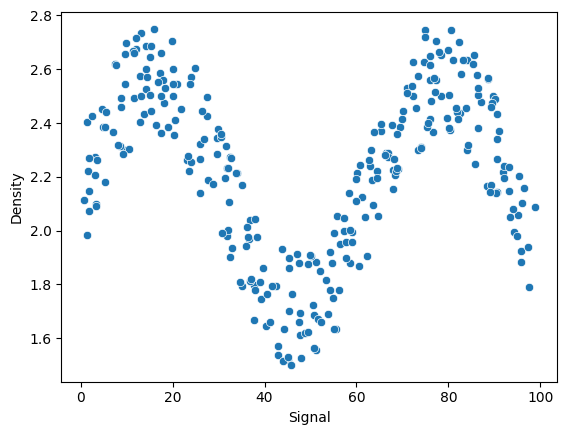

In [9]:
sns.scatterplot(x='Signal', y='Density', data=df)

Данные НЕ лежат на прямой линии. Признак всего один, это легко увидить. Но все равно нужно вычислять метрики.

Масштабирование признаков НЕ нужно, т.к. признак всего один. При большем количестве признаков оно могло бы понадобиться.

In [36]:
X = df['Signal'].values.reshape(-1, 1)

In [37]:
y = df['Density']

In [38]:
from sklearn.model_selection import train_test_split

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=101)

In [40]:
from sklearn.linear_model import LinearRegression

In [41]:
lr_model = LinearRegression()

In [42]:
lr_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [43]:
lr_preds = lr_model.predict(X_test)

In [44]:
lr_preds

array([2.22029657, 2.22047771, 2.22035637, 2.22034337, 2.22039737,
       2.22050555, 2.22042659, 2.22028877, 2.22034673, 2.22029714,
       2.22041506, 2.22050153, 2.22043891, 2.22042003, 2.22047022,
       2.22032403, 2.22033377, 2.22030628, 2.22035154, 2.22035373,
       2.22029266, 2.22036798, 2.22033018, 2.22030611, 2.22042754,
       2.22044019, 2.2204142 , 2.22040303, 2.22048946, 2.22047495])

Выше почти одинаковые предсказания! это почти параллельно оси абсцисс

In [45]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [48]:
np.mean(lr_preds)

np.float64(2.2203865862015713)

In [46]:
mean_absolute_error(y_test, lr_preds)

0.211198973318633

Целевая переменная меняяется в диапазоне [1;2.8]. Неплохая ошибка, на первый взгляд

In [47]:
np.sqrt(mean_squared_error(y_test, lr_preds))

np.float64(0.2570051996584629)

In [51]:
signal_range = np.arange(0, 100)


In [52]:
signal_preds = lr_model.predict(signal_range.reshape(-1, 1))

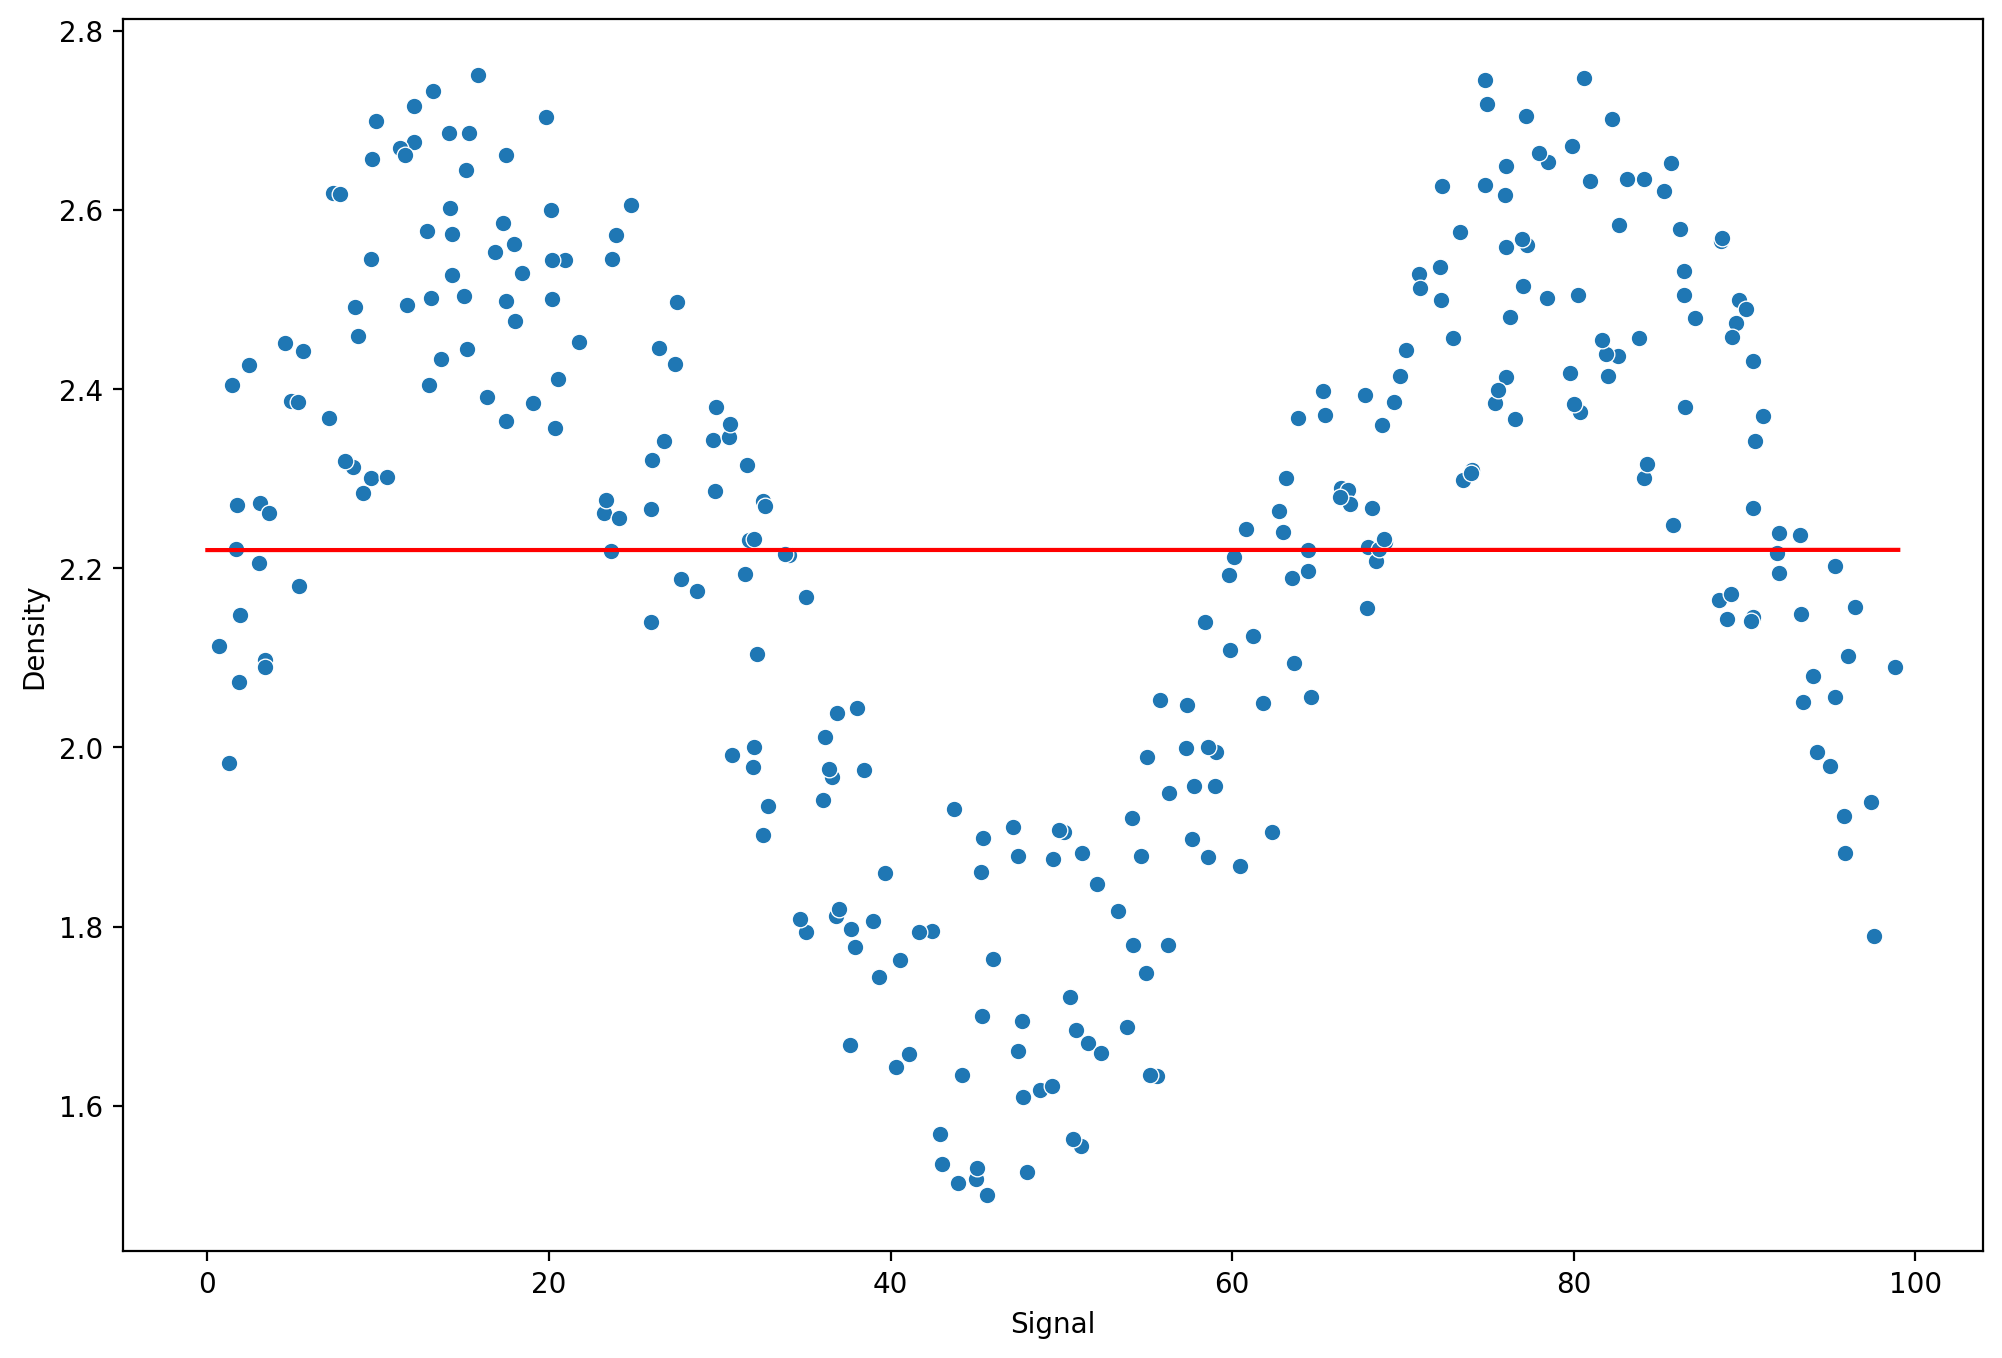

In [53]:
plt.figure(figsize=(12, 8), dpi=200)
sns.scatterplot(x=df['Signal'], y=df['Density'])

plt.plot(signal_range, signal_preds, c='r')

При приемлемых метриках вот такой фиговый график

Построим график остатков.

In [54]:
lr_residuals = y_test - lr_preds

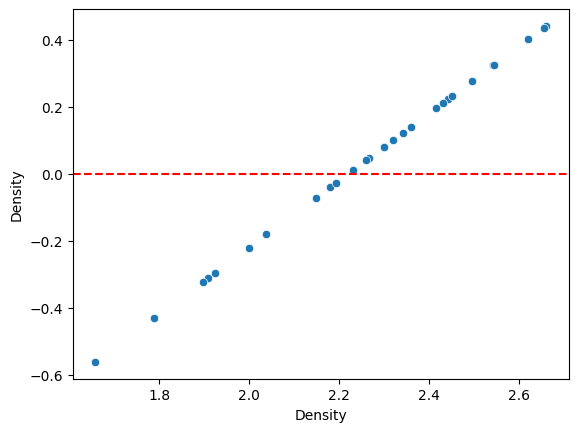

In [59]:
sns.scatterplot(x=y_test, y=lr_residuals)
plt.axhline(0, ls='--', c='r')

Линейная модель НЕ ПОДХОДИТ для наших данных

Проверим полиномиальную модель

In [60]:
def run_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    
    preds = model.predict(X_test)
    
    RMSE = np.sqrt(mean_squared_error(y_test, preds))
    MAE = mean_absolute_error(y_test, preds)
    print(f"RMSE: {RMSE}")
    print(f"MAE: {MAE}")
    
    signal_range = np.arange(0, 100)
    signal_preds = model.predict(signal_range.reshape(-1, 1))

    plt.figure(figsize=(12, 8), dpi=200)
    sns.scatterplot(x=df['Signal'], y=df['Density'], color='green')
    plt.plot(signal_range, signal_preds, c='r')

RMSE: 0.2570051996584629
MAE: 0.211198973318633


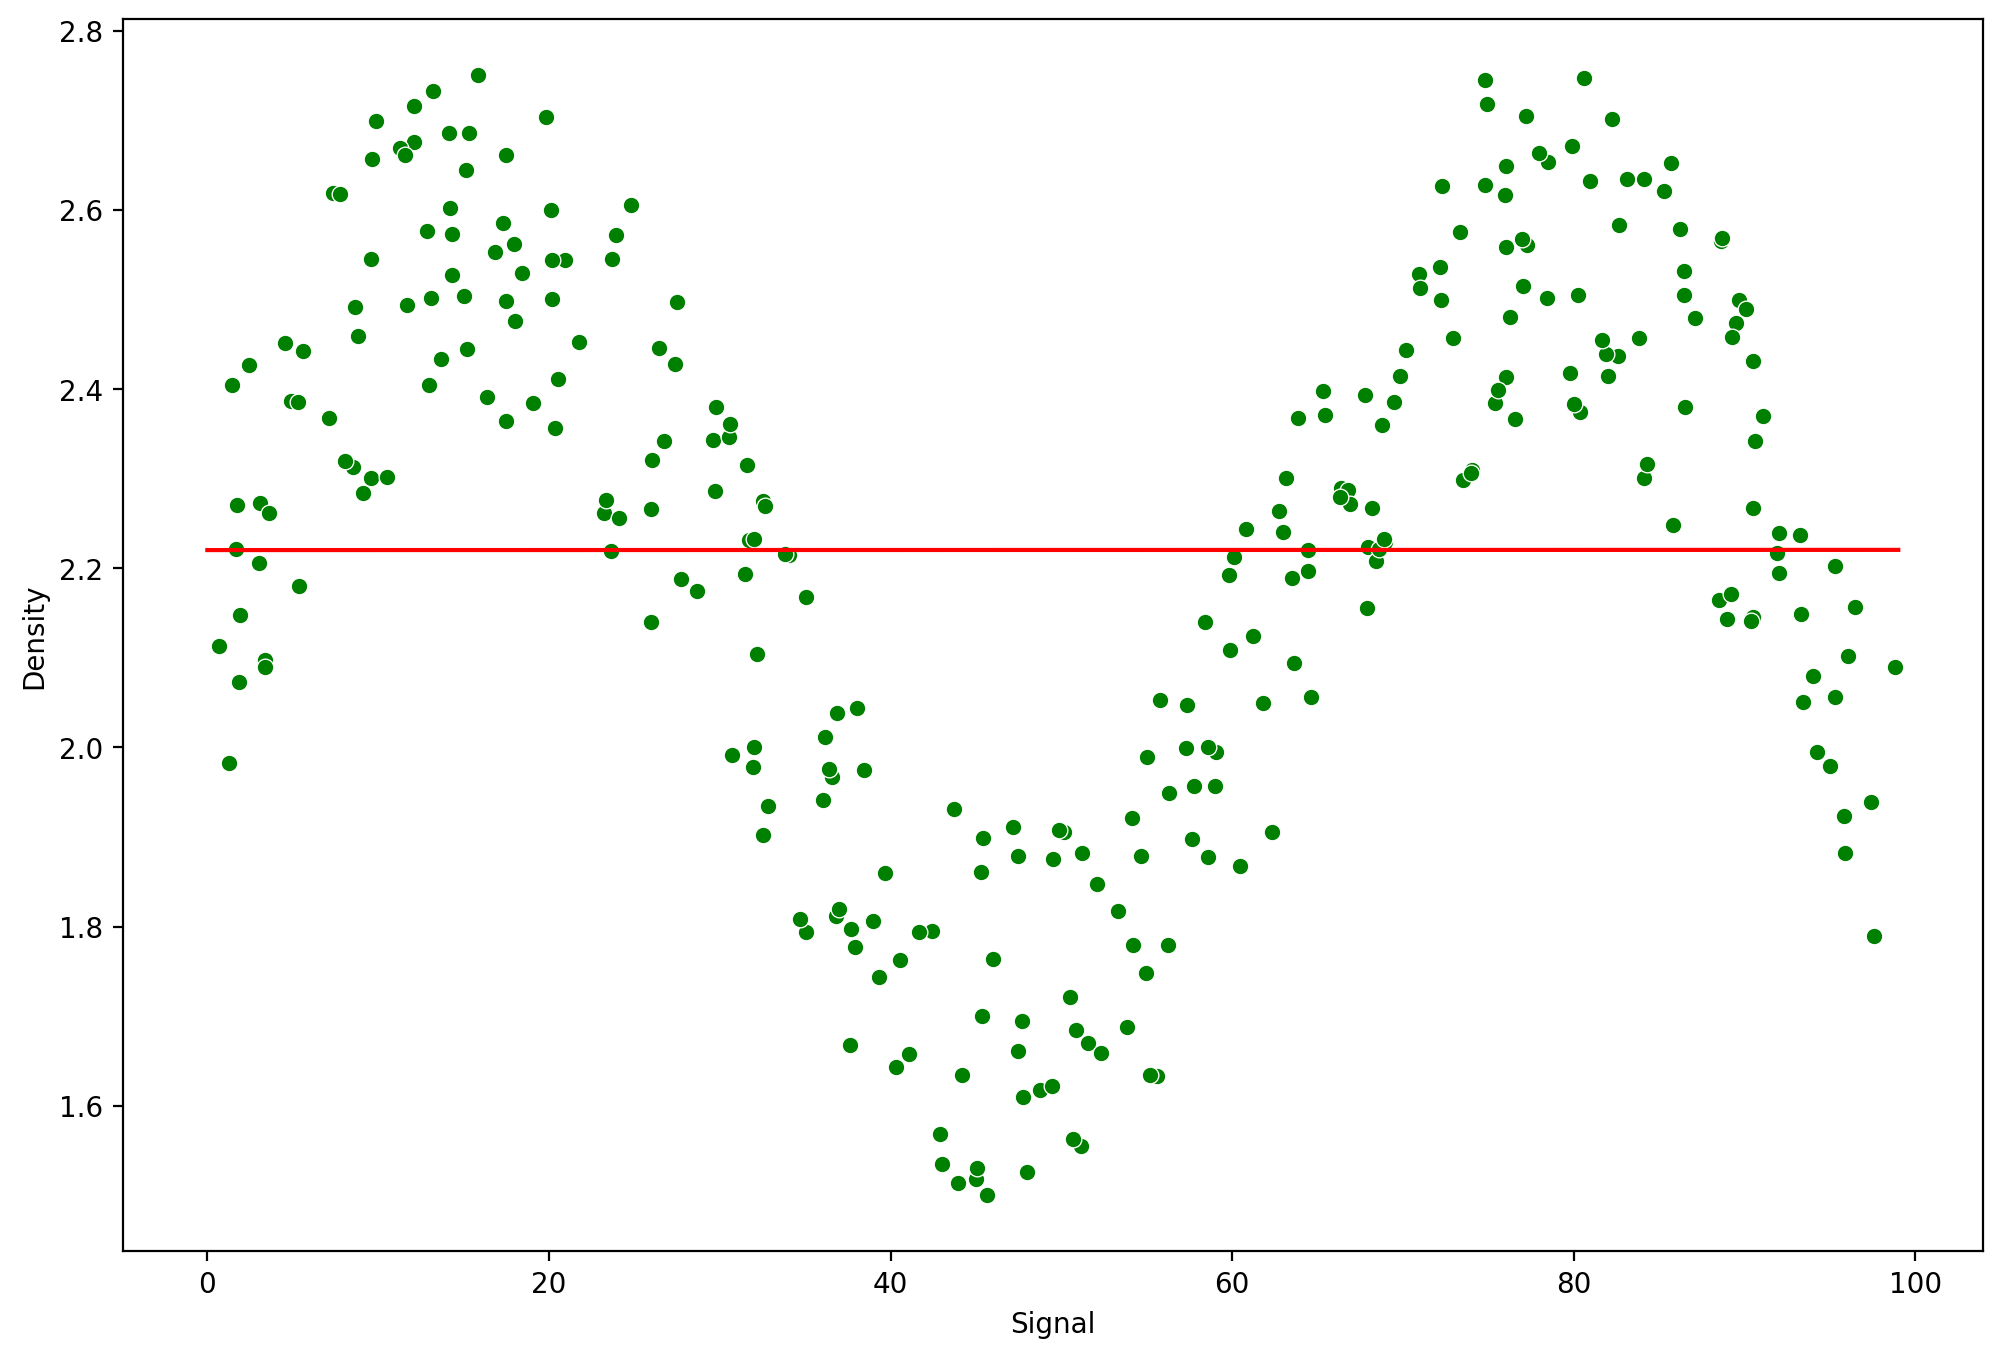

In [61]:
run_model(LinearRegression(), X_train, y_train, X_test, y_test)

Создадим полиномиальные признаки!

In [62]:
from sklearn.pipeline import make_pipeline

In [63]:
from sklearn.preprocessing import PolynomialFeatures

In [70]:
pipe = make_pipeline(PolynomialFeatures(degree=6), LinearRegression())

RMSE: 0.13807520083403252
MAE: 0.11969168049270058


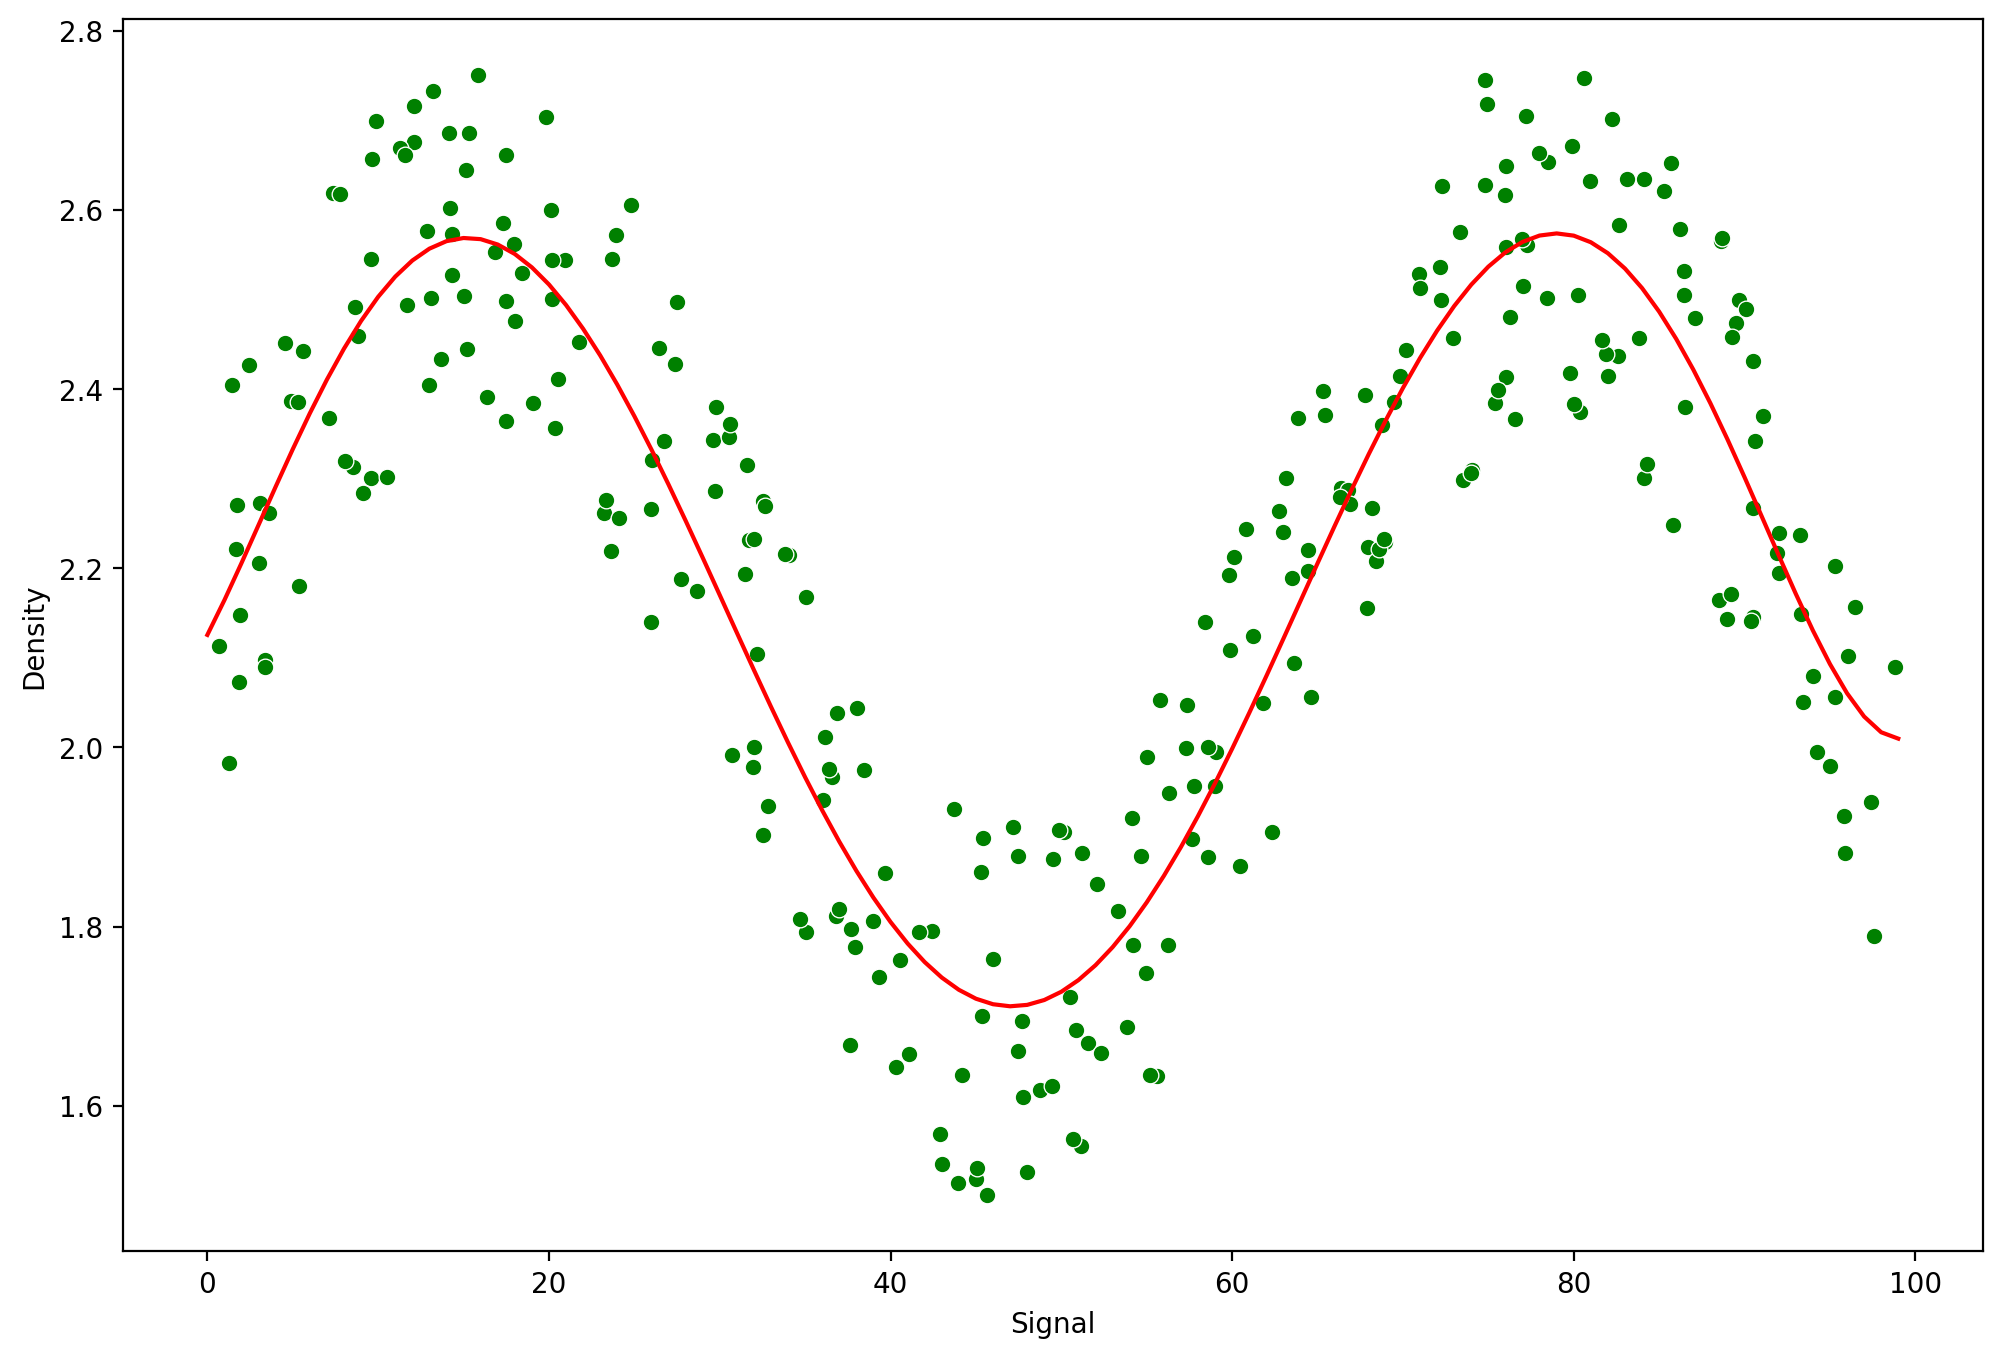

In [71]:
run_model(pipe, X_train, y_train, X_test, y_test)

Полином степени 6 показывает хорошие результаты, если мы уверены, что на вход будут поданы данные в [0;100]

In [73]:
RMSE_list = []
MAE_list = []
for i in range(1, 11):
    pipe = make_pipeline(PolynomialFeatures(degree=i), LinearRegression())
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    
    RMSE = np.sqrt(mean_squared_error(y_test, preds))
    RMSE_list.append(RMSE)
    MAE = mean_absolute_error(y_test, preds)
    MAE_list.append(MAE)
    
    

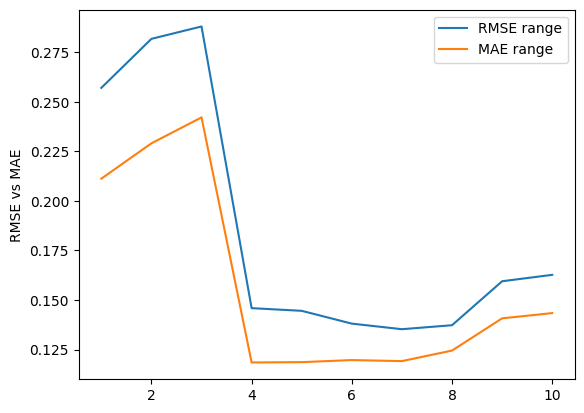

In [75]:
plt.plot(range(1, 11), RMSE_list, label='RMSE range')
plt.plot(range(1, 11),MAE_list, label='MAE range')
plt.ylabel('RMSE vs MAE')
plt.legend()

## KNN for Regression**

In [76]:
from sklearn.neighbors import KNeighborsRegressor

In [77]:
k_values = [1, 5, 10]

RMSE: 0.1523487028635337
MAE: 0.11877297474442378
The metrics above are for 1 nearest neighbors
RMSE: 0.13730685016923647
MAE: 0.12198383614100558
The metrics above are for 5 nearest neighbors
RMSE: 0.13277855732740926
MAE: 0.11635971693292672
The metrics above are for 10 nearest neighbors


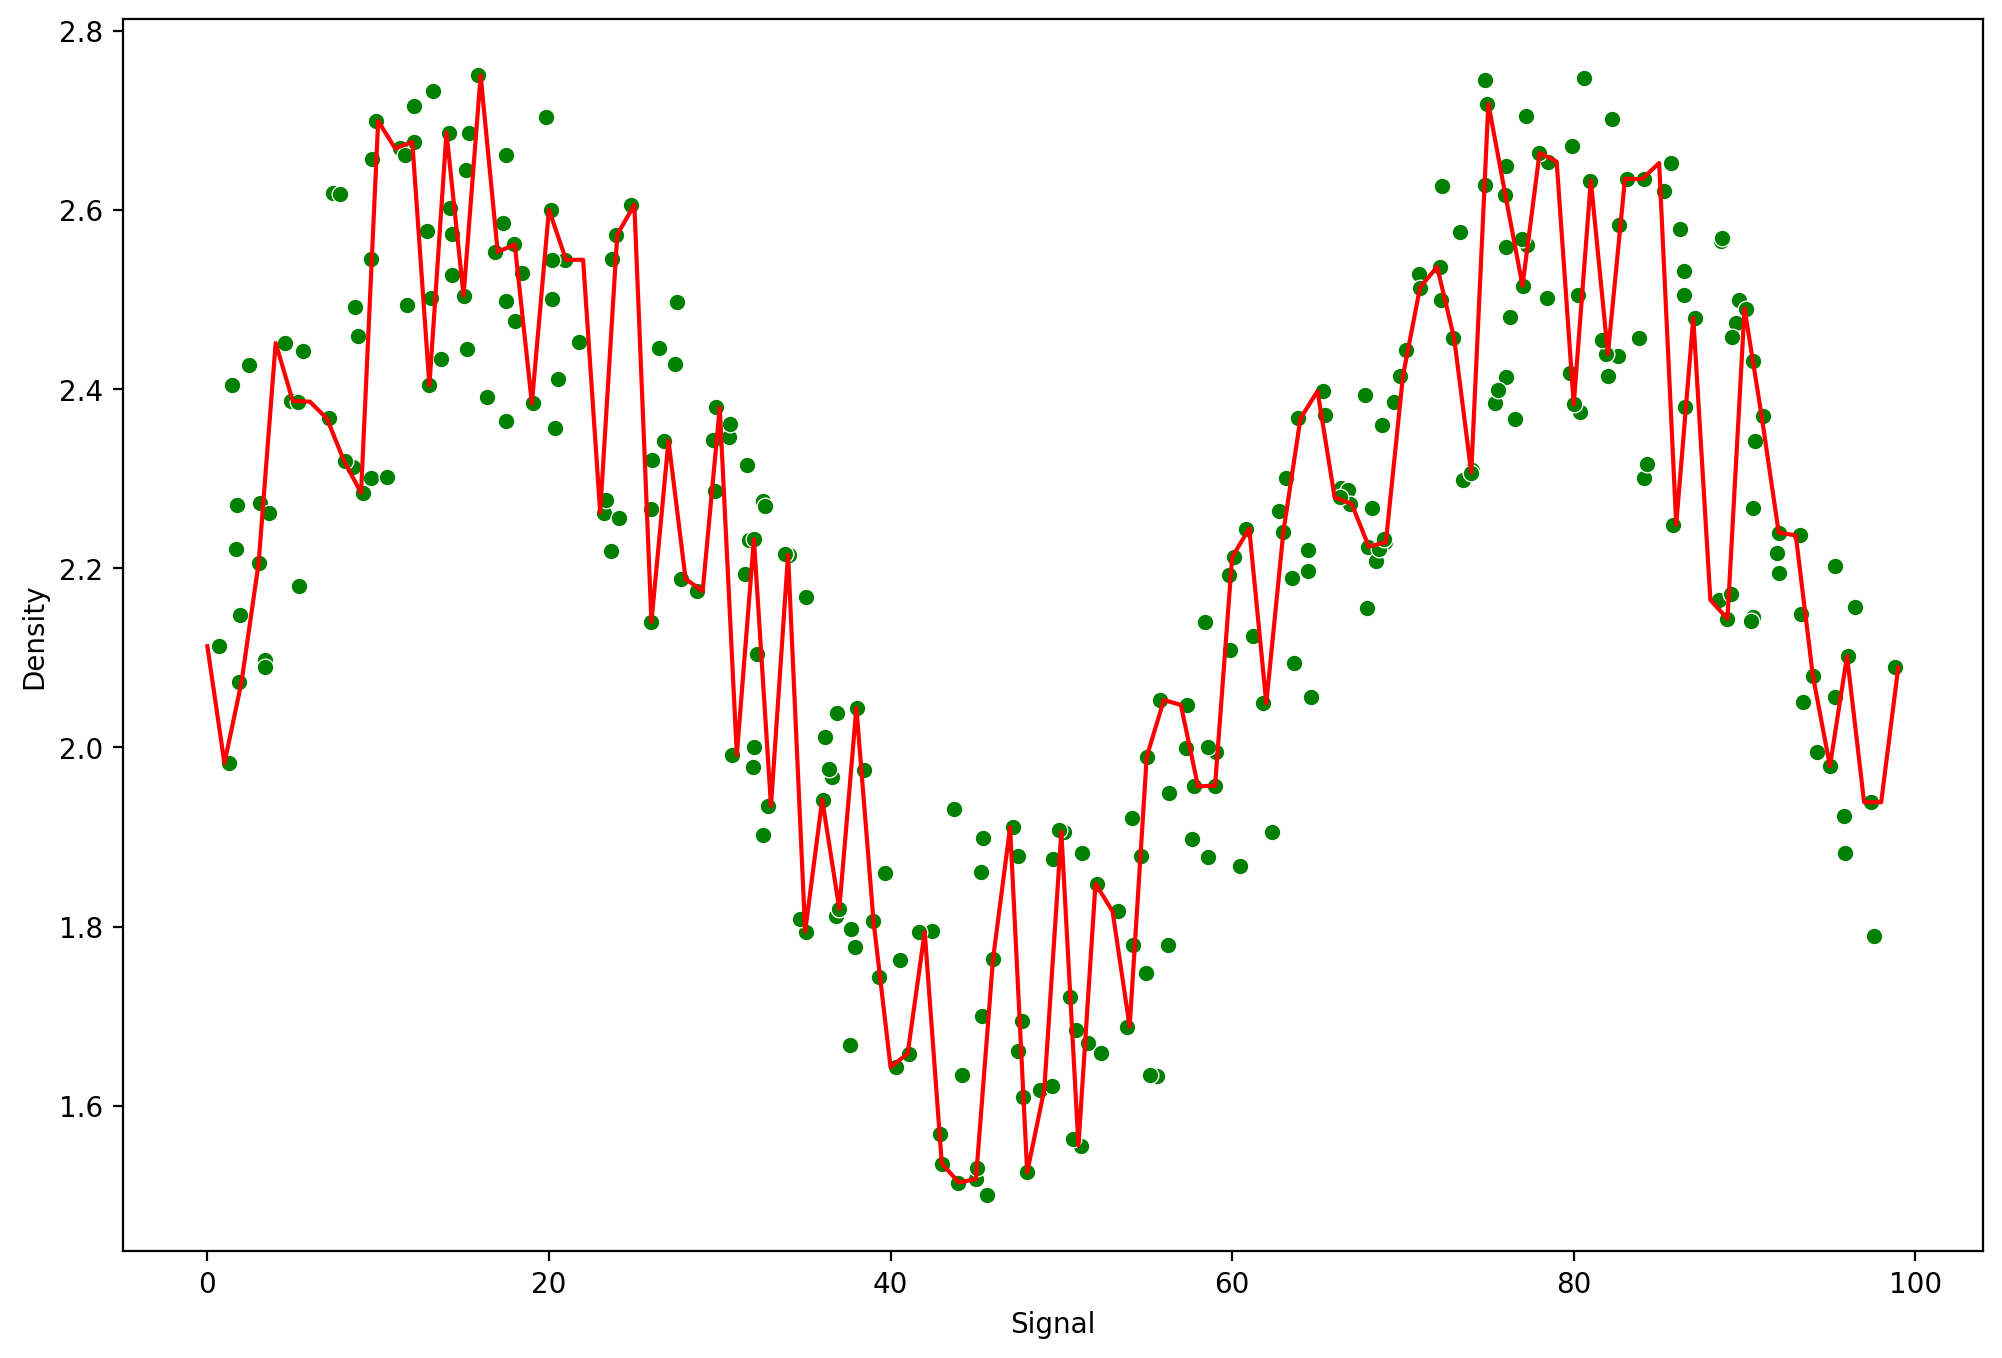

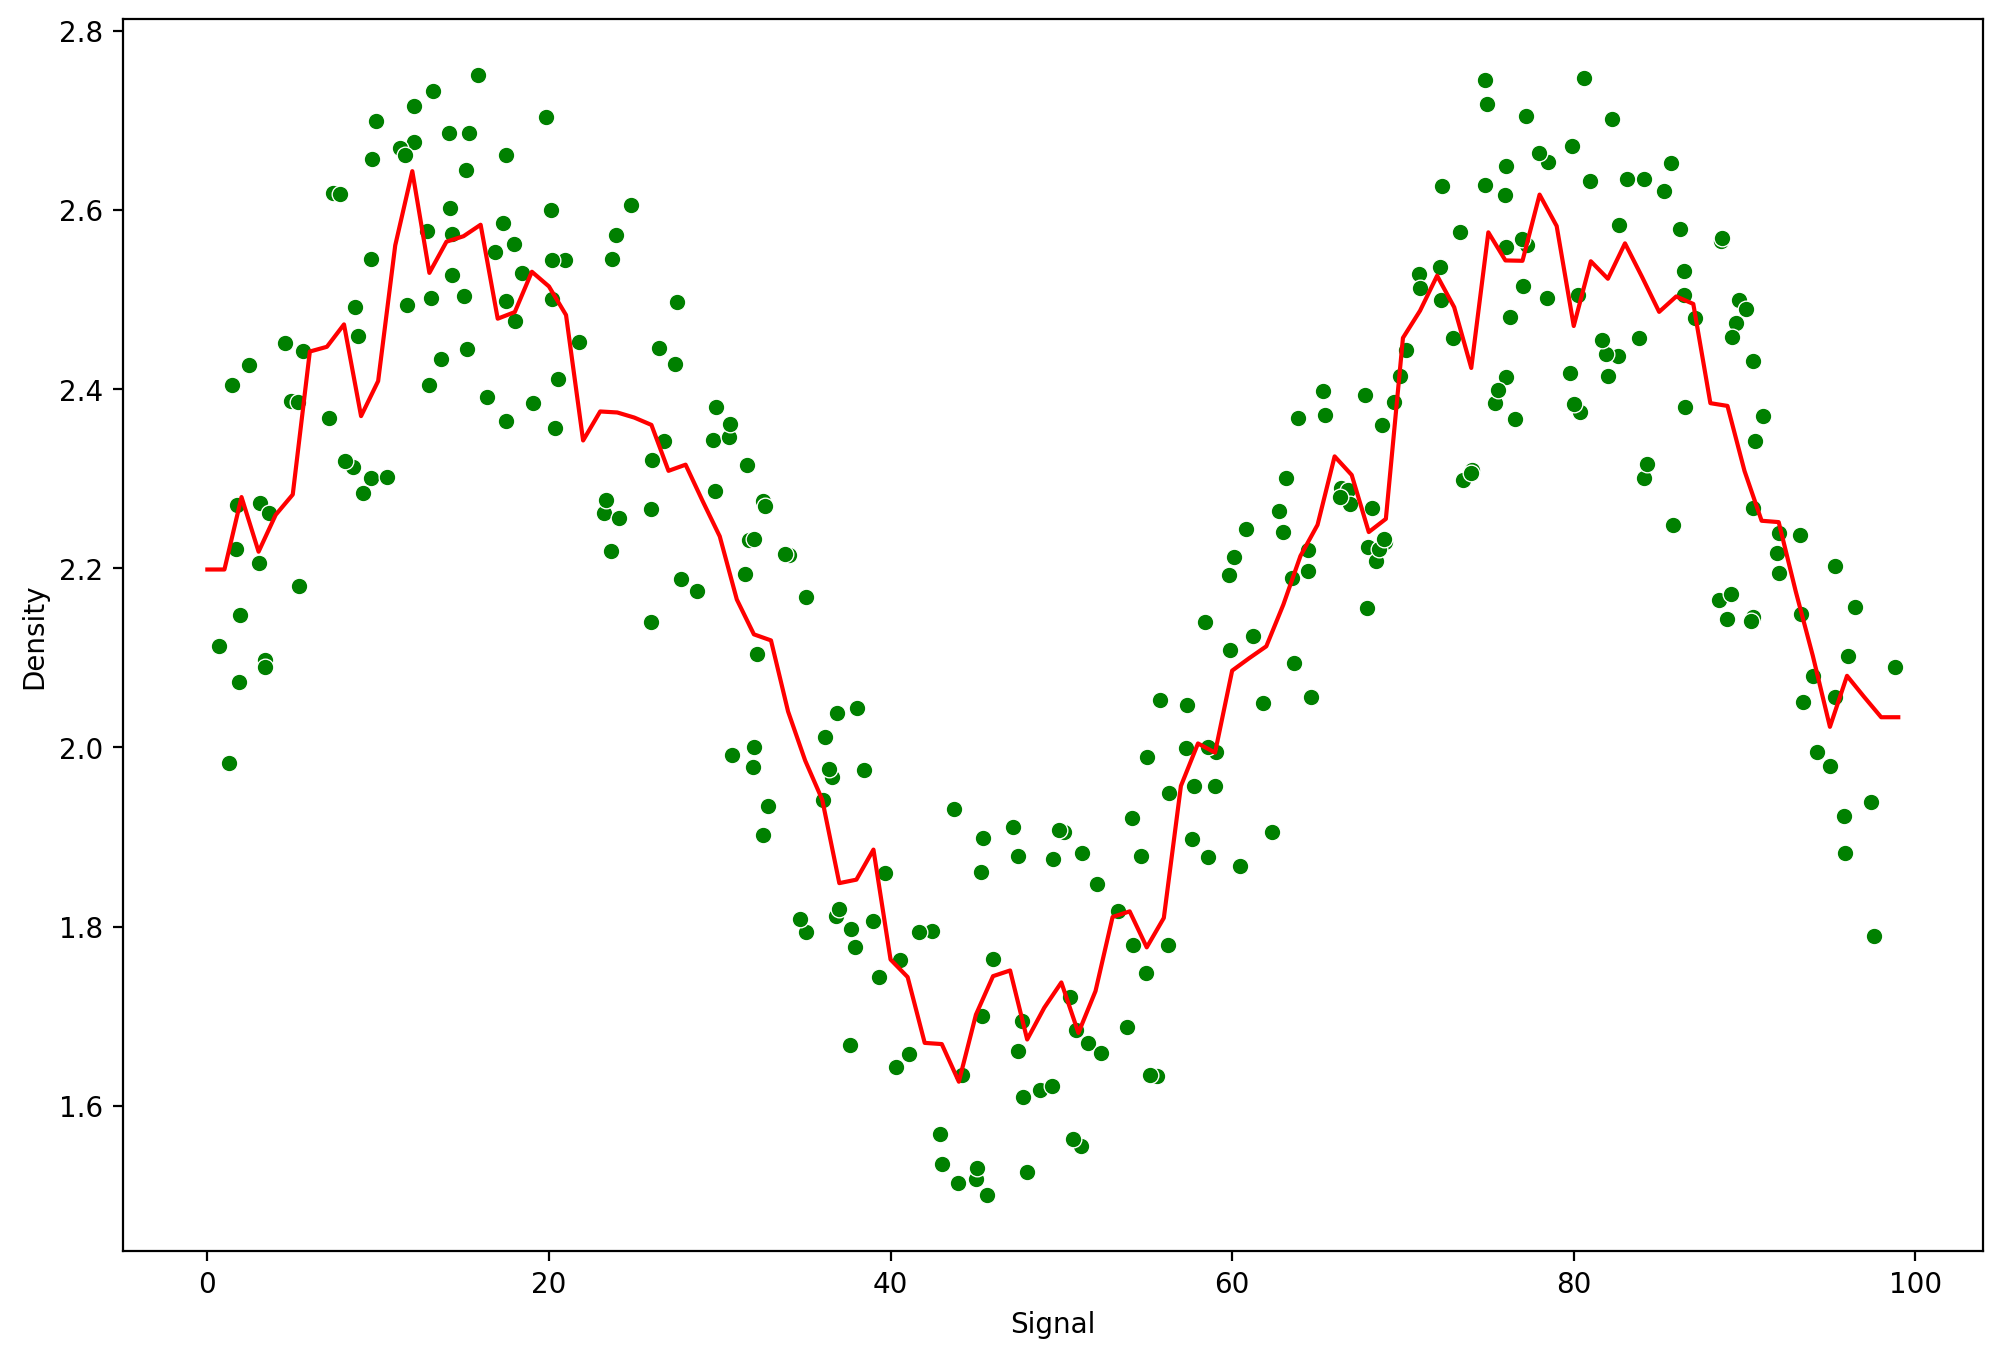

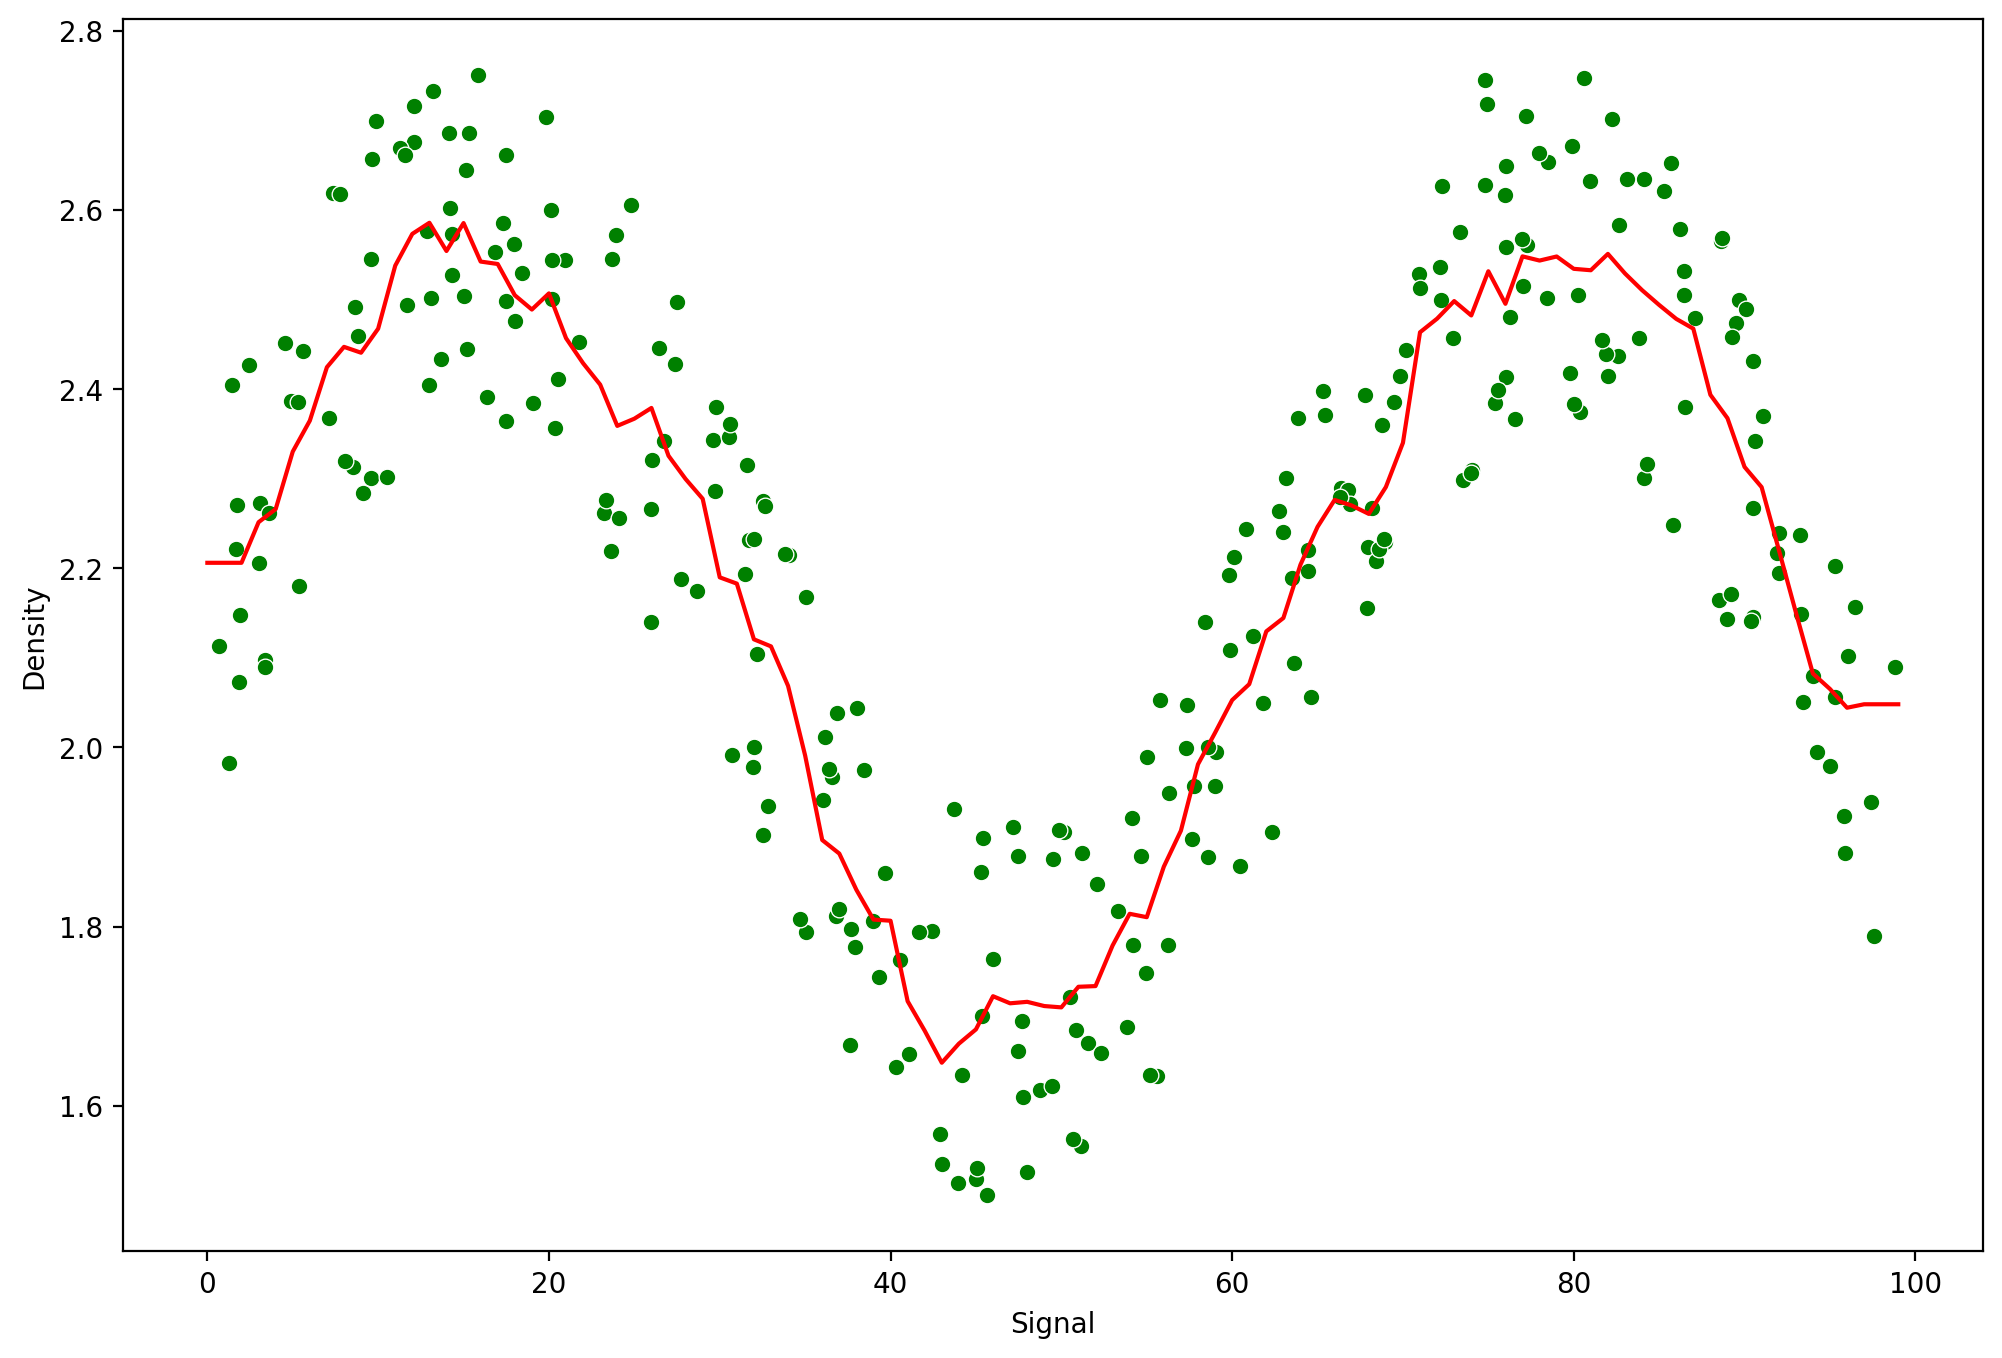

In [78]:
for k in k_values:
    model = KNeighborsRegressor(n_neighbors=k)
    run_model(model, X_train, y_train, X_test, y_test)
    print(f'The metrics above are for {k} nearest neighbors')

RMSE: 0.15954234753677107
MAE: 0.13363165935705318
The metrics above are for 30 nearest neighbors


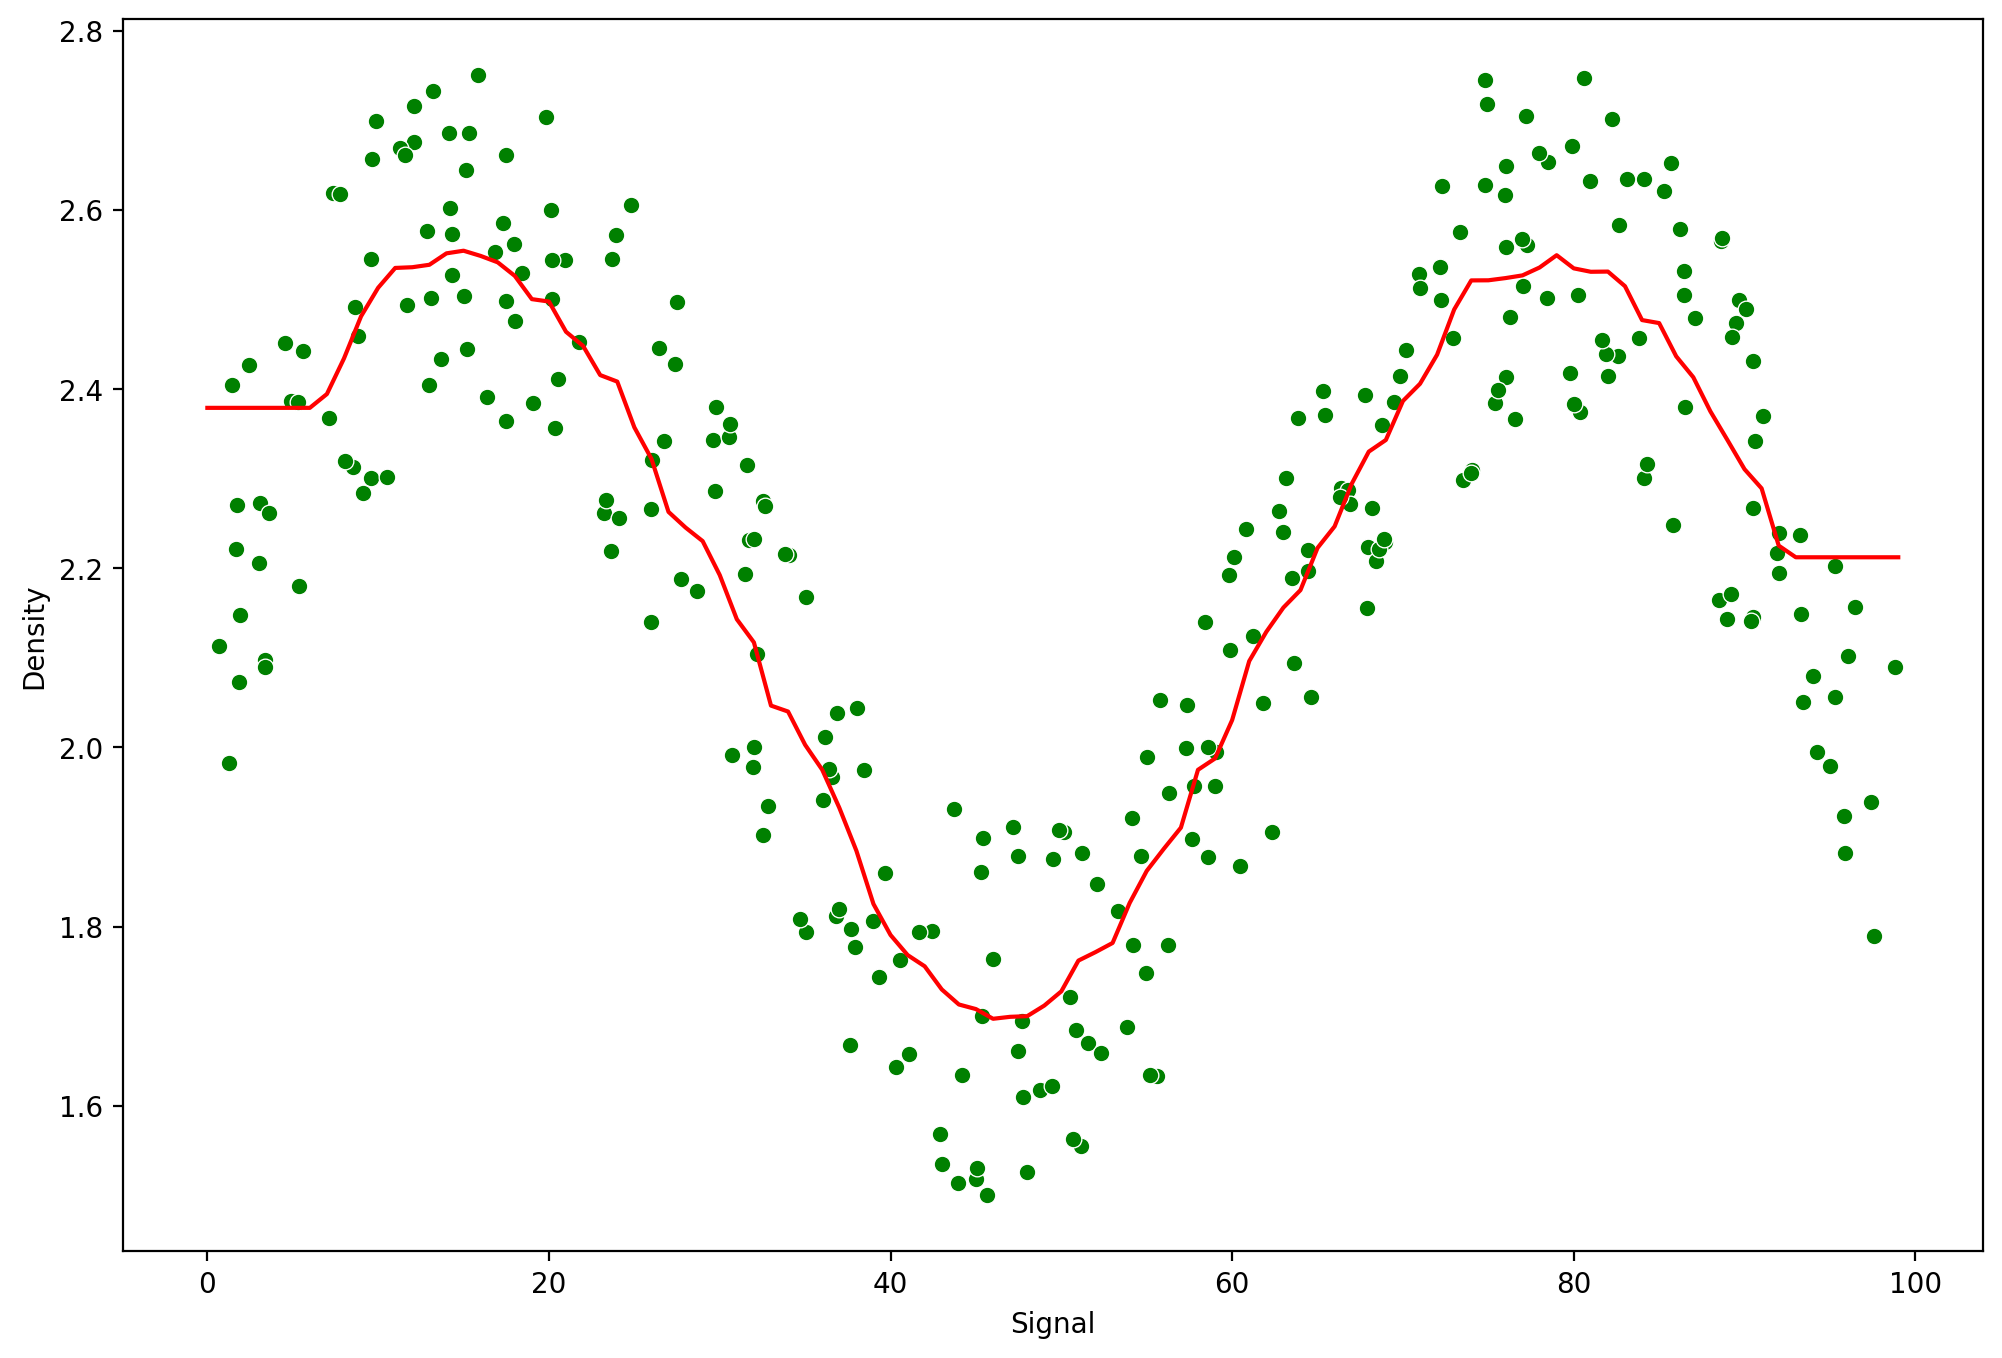

In [79]:
model = KNeighborsRegressor(n_neighbors=30)
run_model(model, X_train, y_train, X_test, y_test)
print(f'The metrics above are for 30 nearest neighbors')

## **Decision Tree for Regression**

In [87]:
from sklearn.tree import DecisionTreeRegressor

RMSE: 0.1523487028635337
MAE: 0.11877297474442378


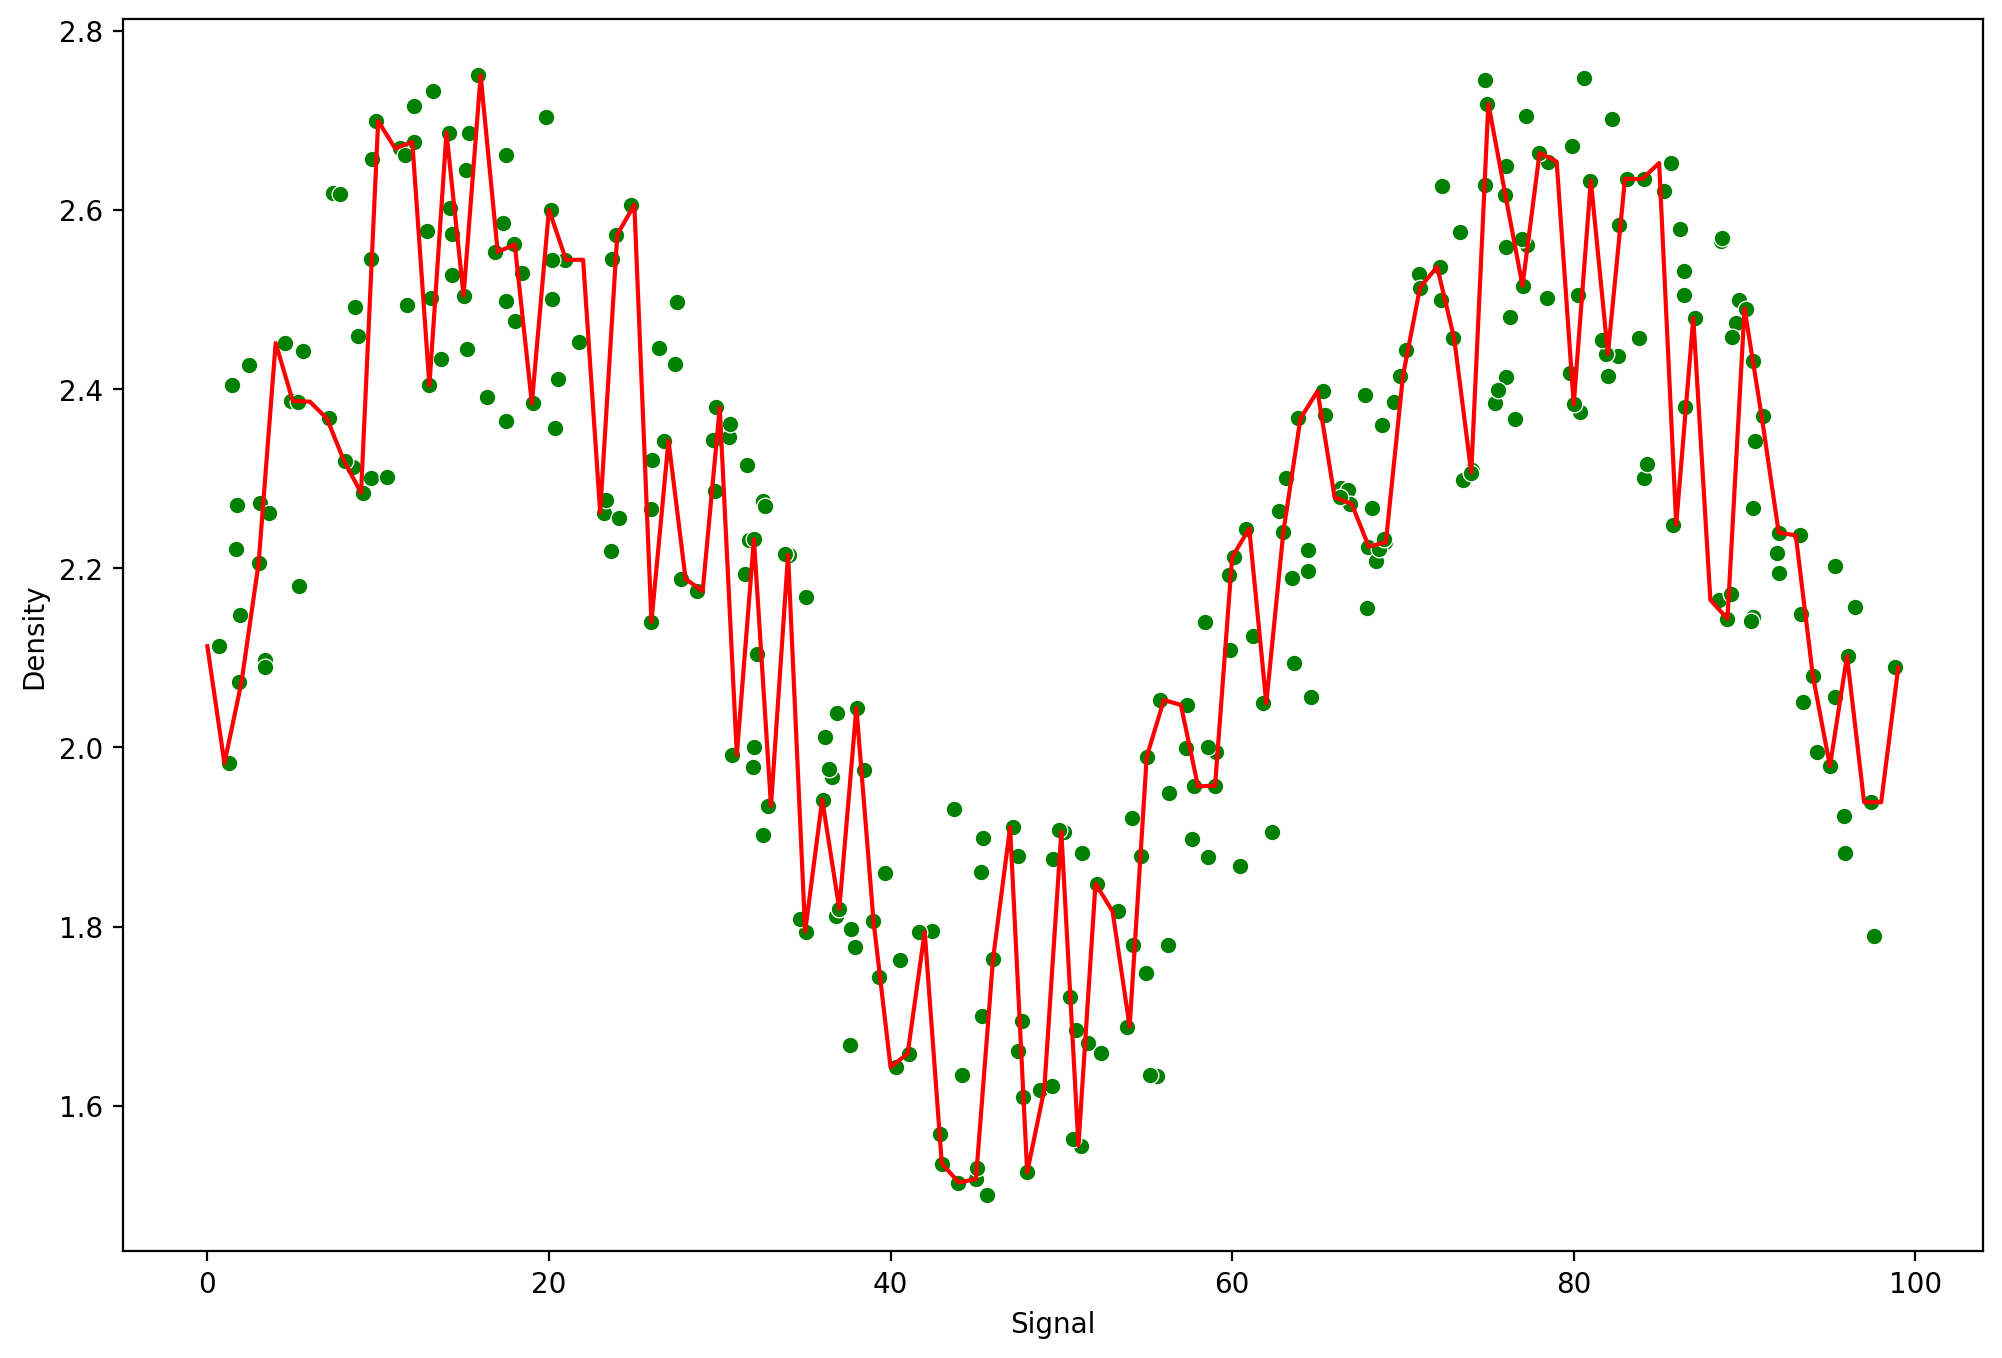

In [81]:
model = DecisionTreeRegressor()

run_model(model, X_train, y_train, X_test, y_test)
# модель очень отвлекается на шумы в данных

## **Support Vector Machines for Regression**

In [82]:
from sklearn.svm import SVR

In [83]:
from sklearn.model_selection import GridSearchCV

In [84]:
svr = SVR()
param_grid = {"C": [.01, .01, 1, 5, 10, 100, 1000], 
              "gamma": ['auto', 'scale']
             } 

grid = GridSearchCV(svr, param_grid)

RMSE: 0.12646999302046696
MAE: 0.10854210121348368


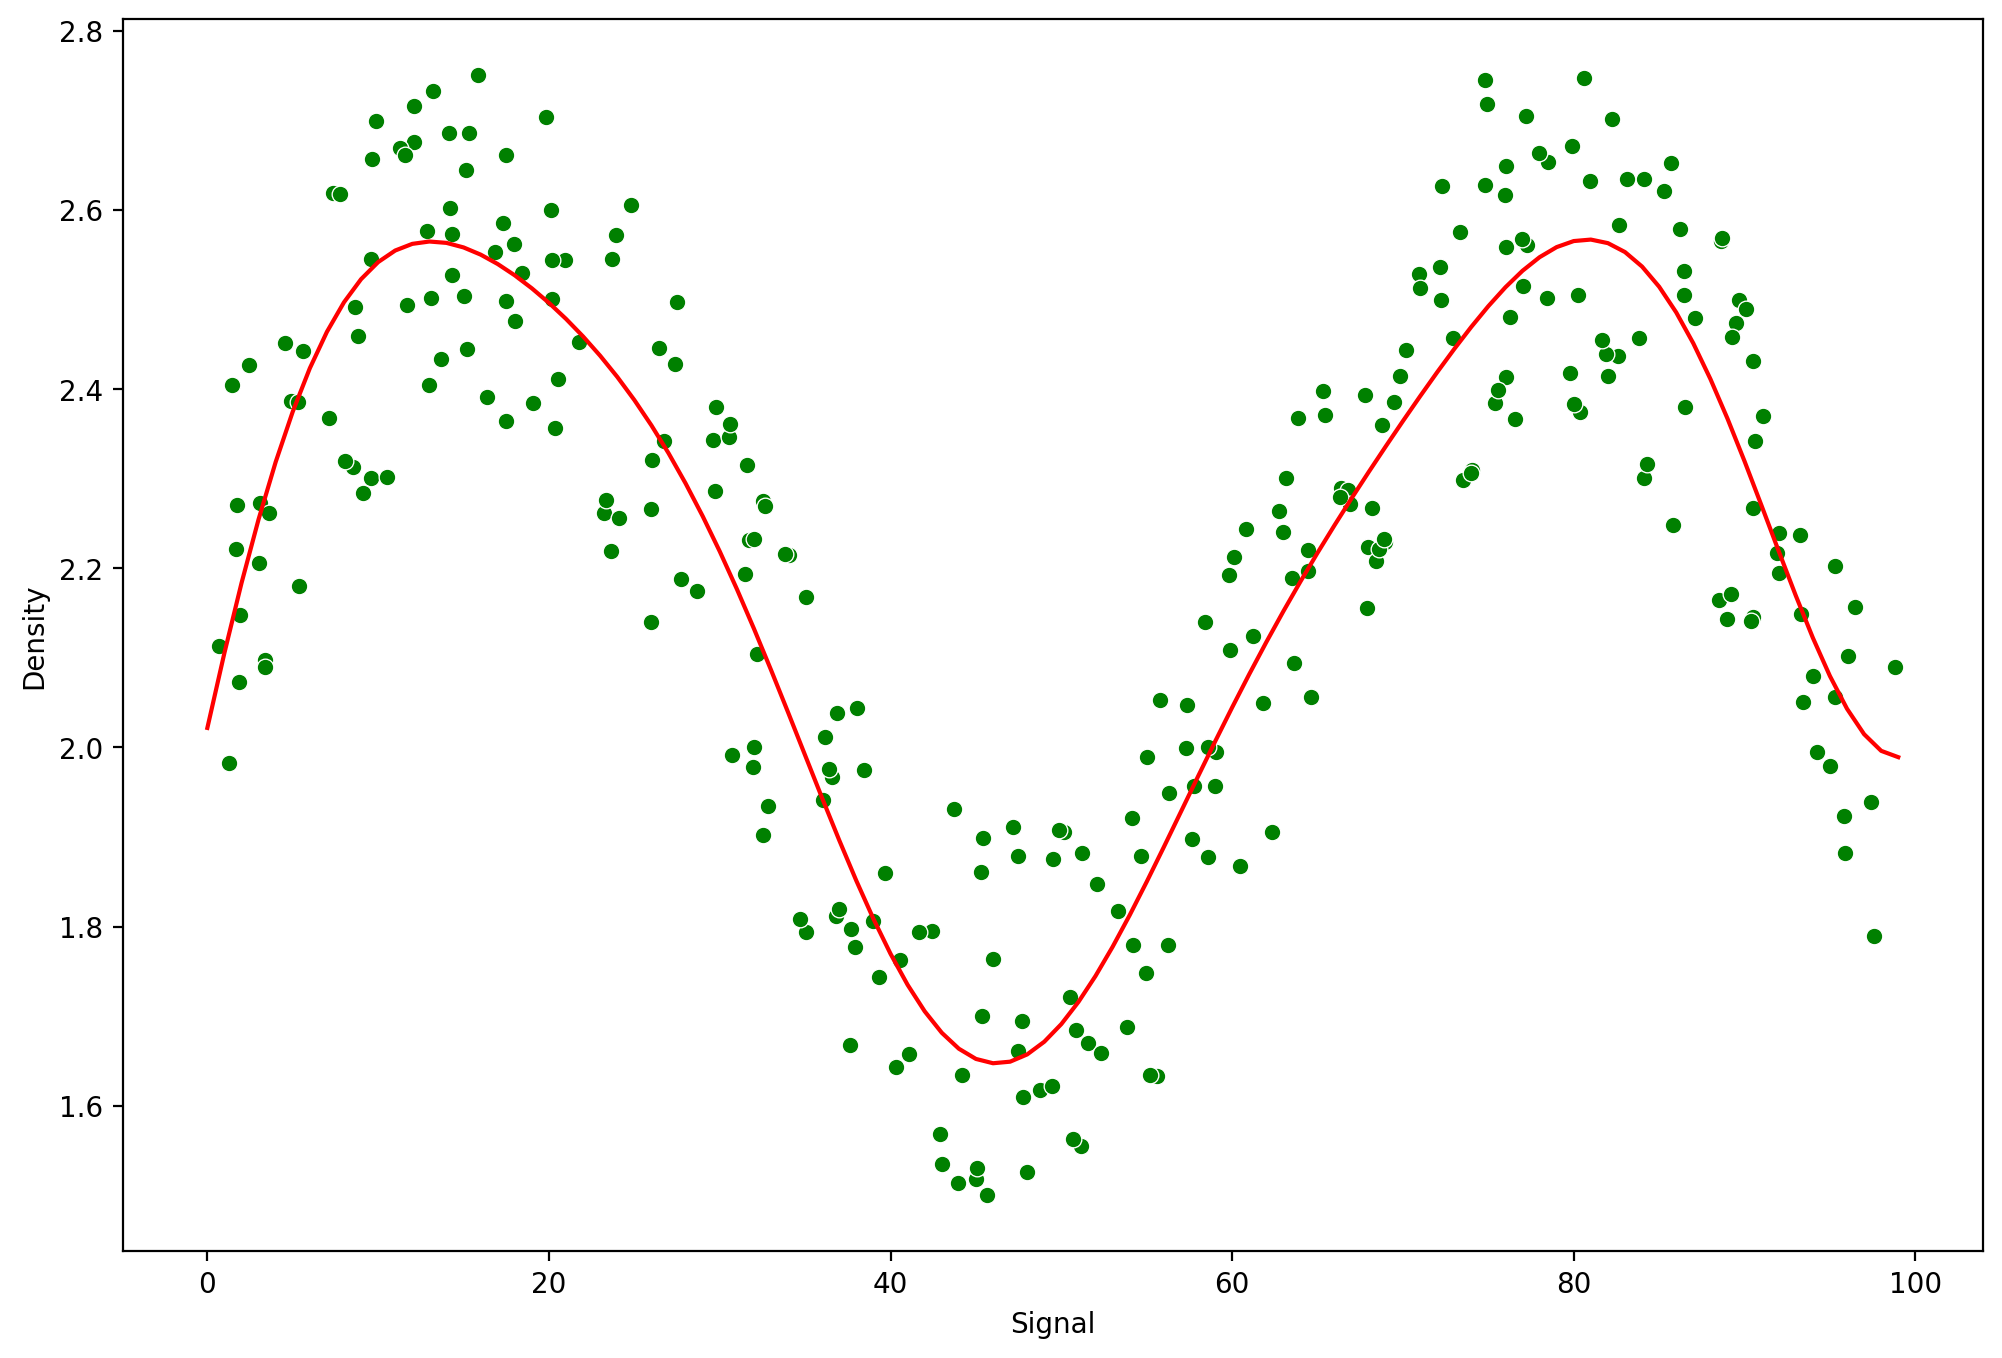

In [85]:
run_model(grid, X_train, y_train, X_test, y_test)


In [86]:
grid.best_params_

{'C': 1000, 'gamma': 'scale'}

## **Random Forest for Regression**

In [88]:
from sklearn.ensemble import RandomForestRegressor

In [89]:
rfr = RandomForestRegressor(n_estimators=10)

RMSE: 0.14605419713042372
MAE: 0.11771901068646291


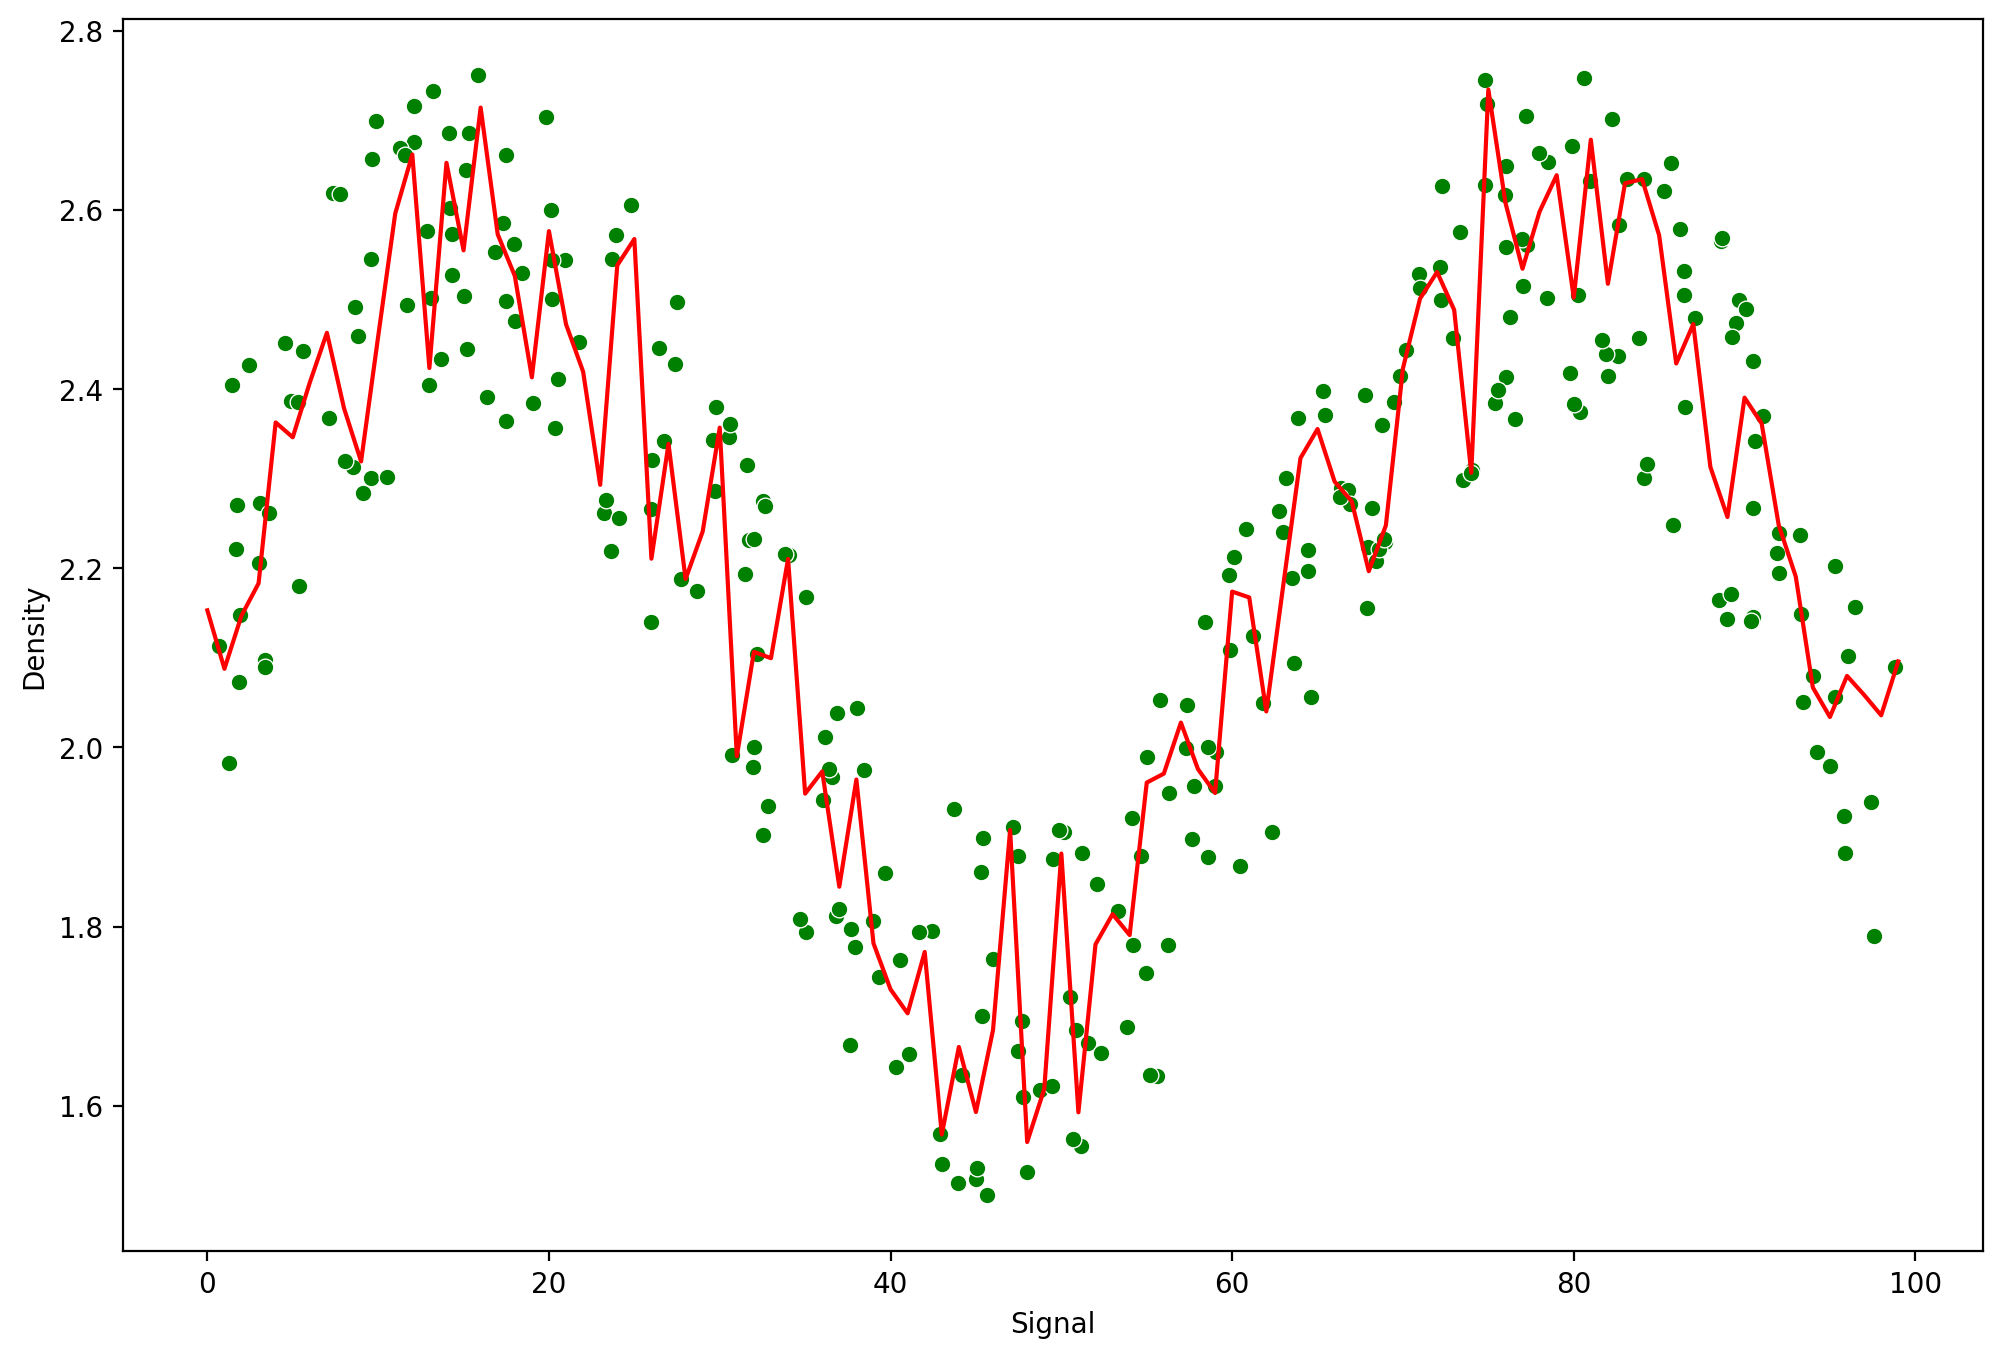

In [90]:
run_model(rfr, X_train, y_train, X_test, y_test)


## **Boosted Trees for Regression**

In [91]:
from sklearn.ensemble import GradientBoostingRegressor, AdaBoostRegressor

In this particulat case GradientBoostingregressor works better than Random Forest

RMSE: 0.13294148649584667
MAE: 0.11318284854800689


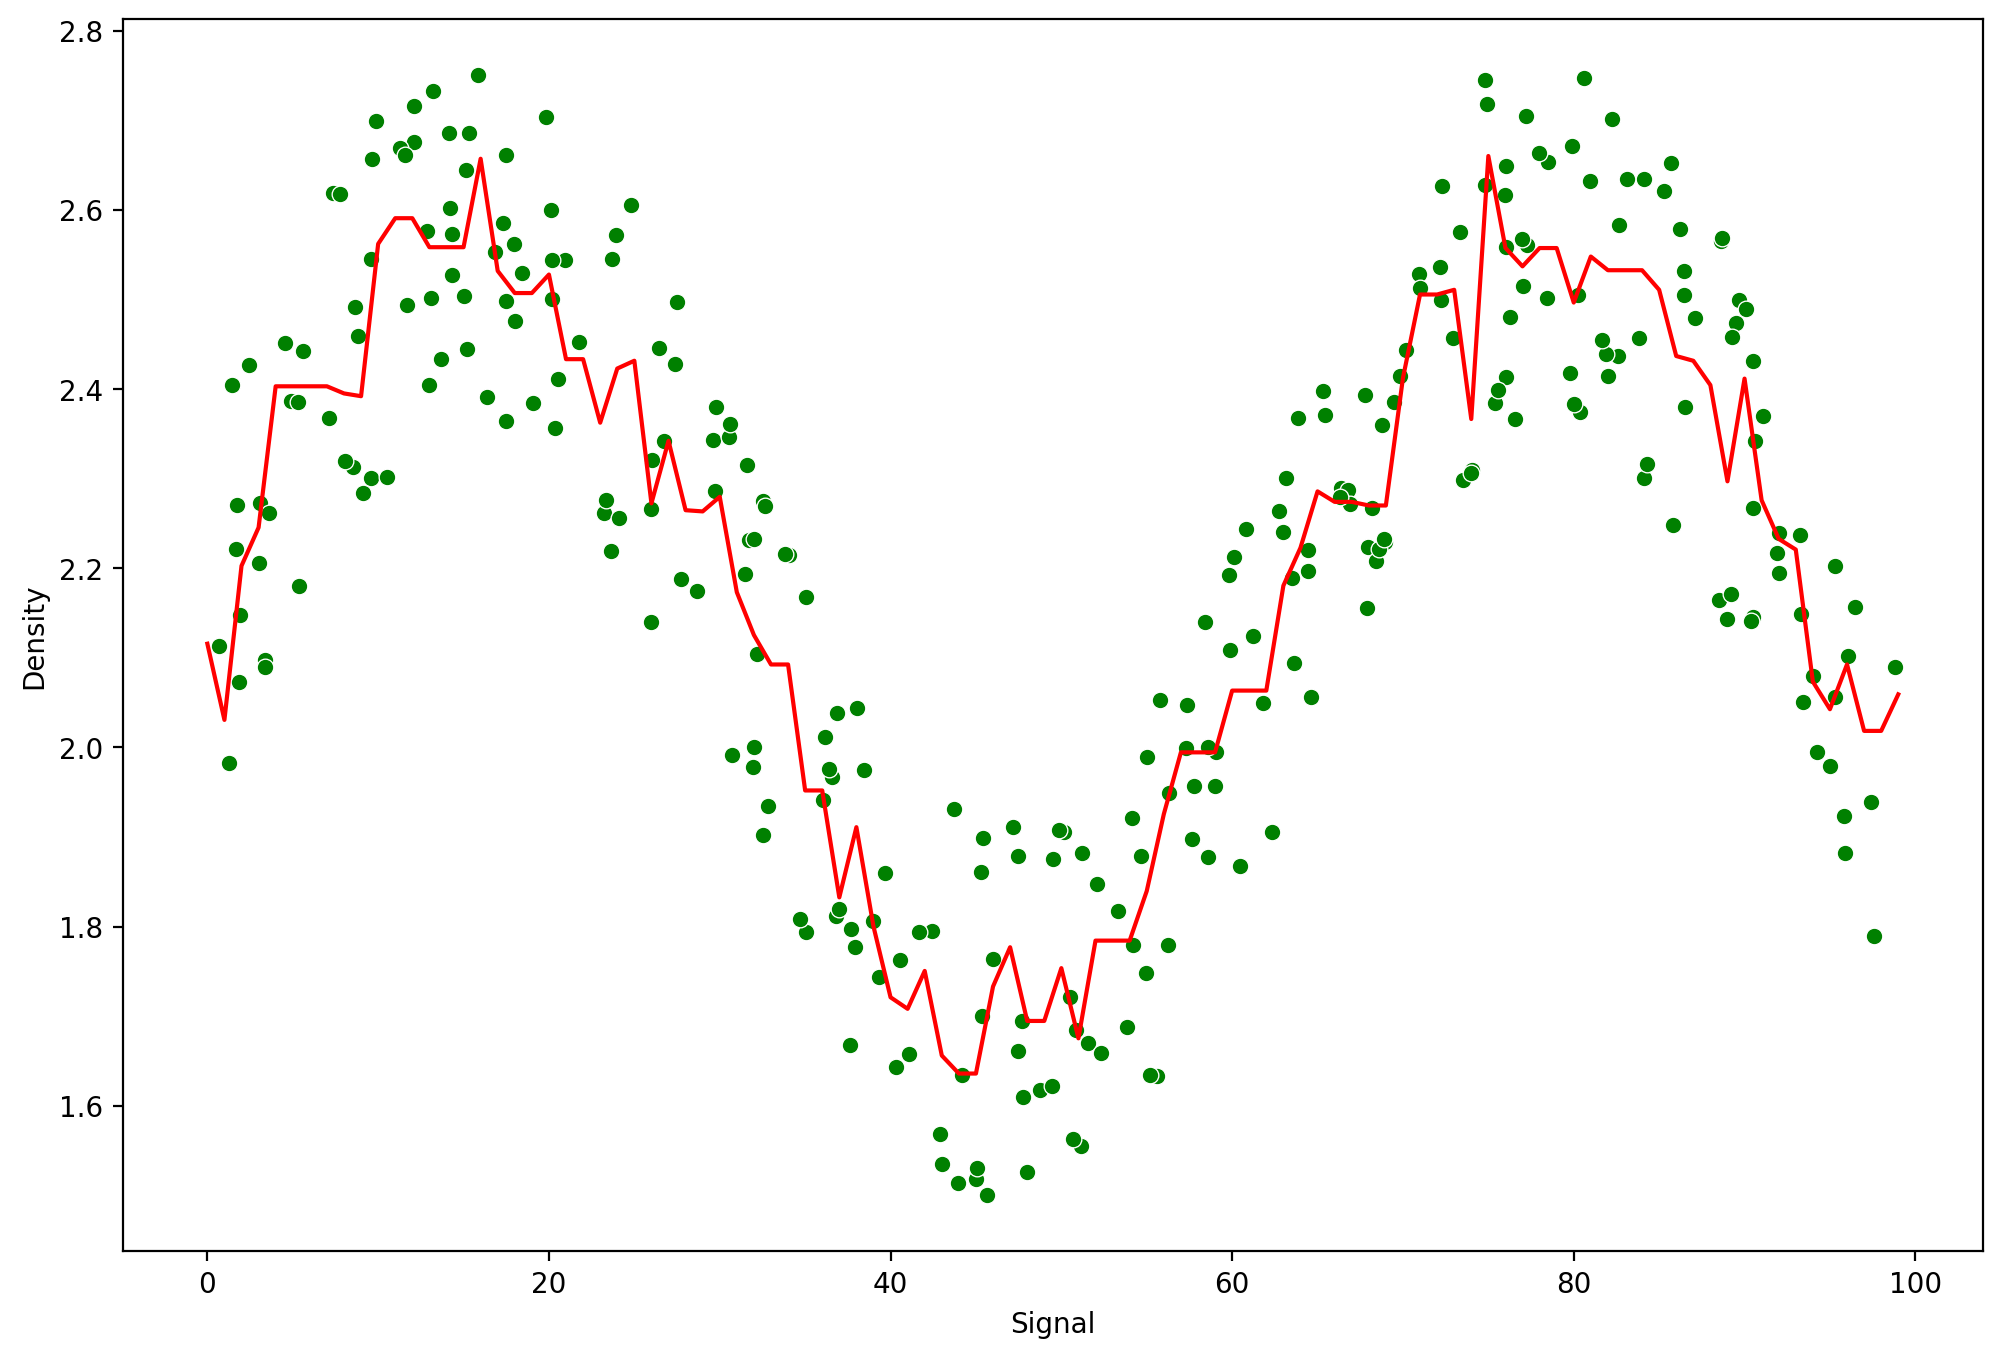

In [92]:
model = GradientBoostingRegressor()
run_model(model, X_train, y_train, X_test, y_test)

RMSE: 0.13942141328315966
MAE: 0.1206595853566351


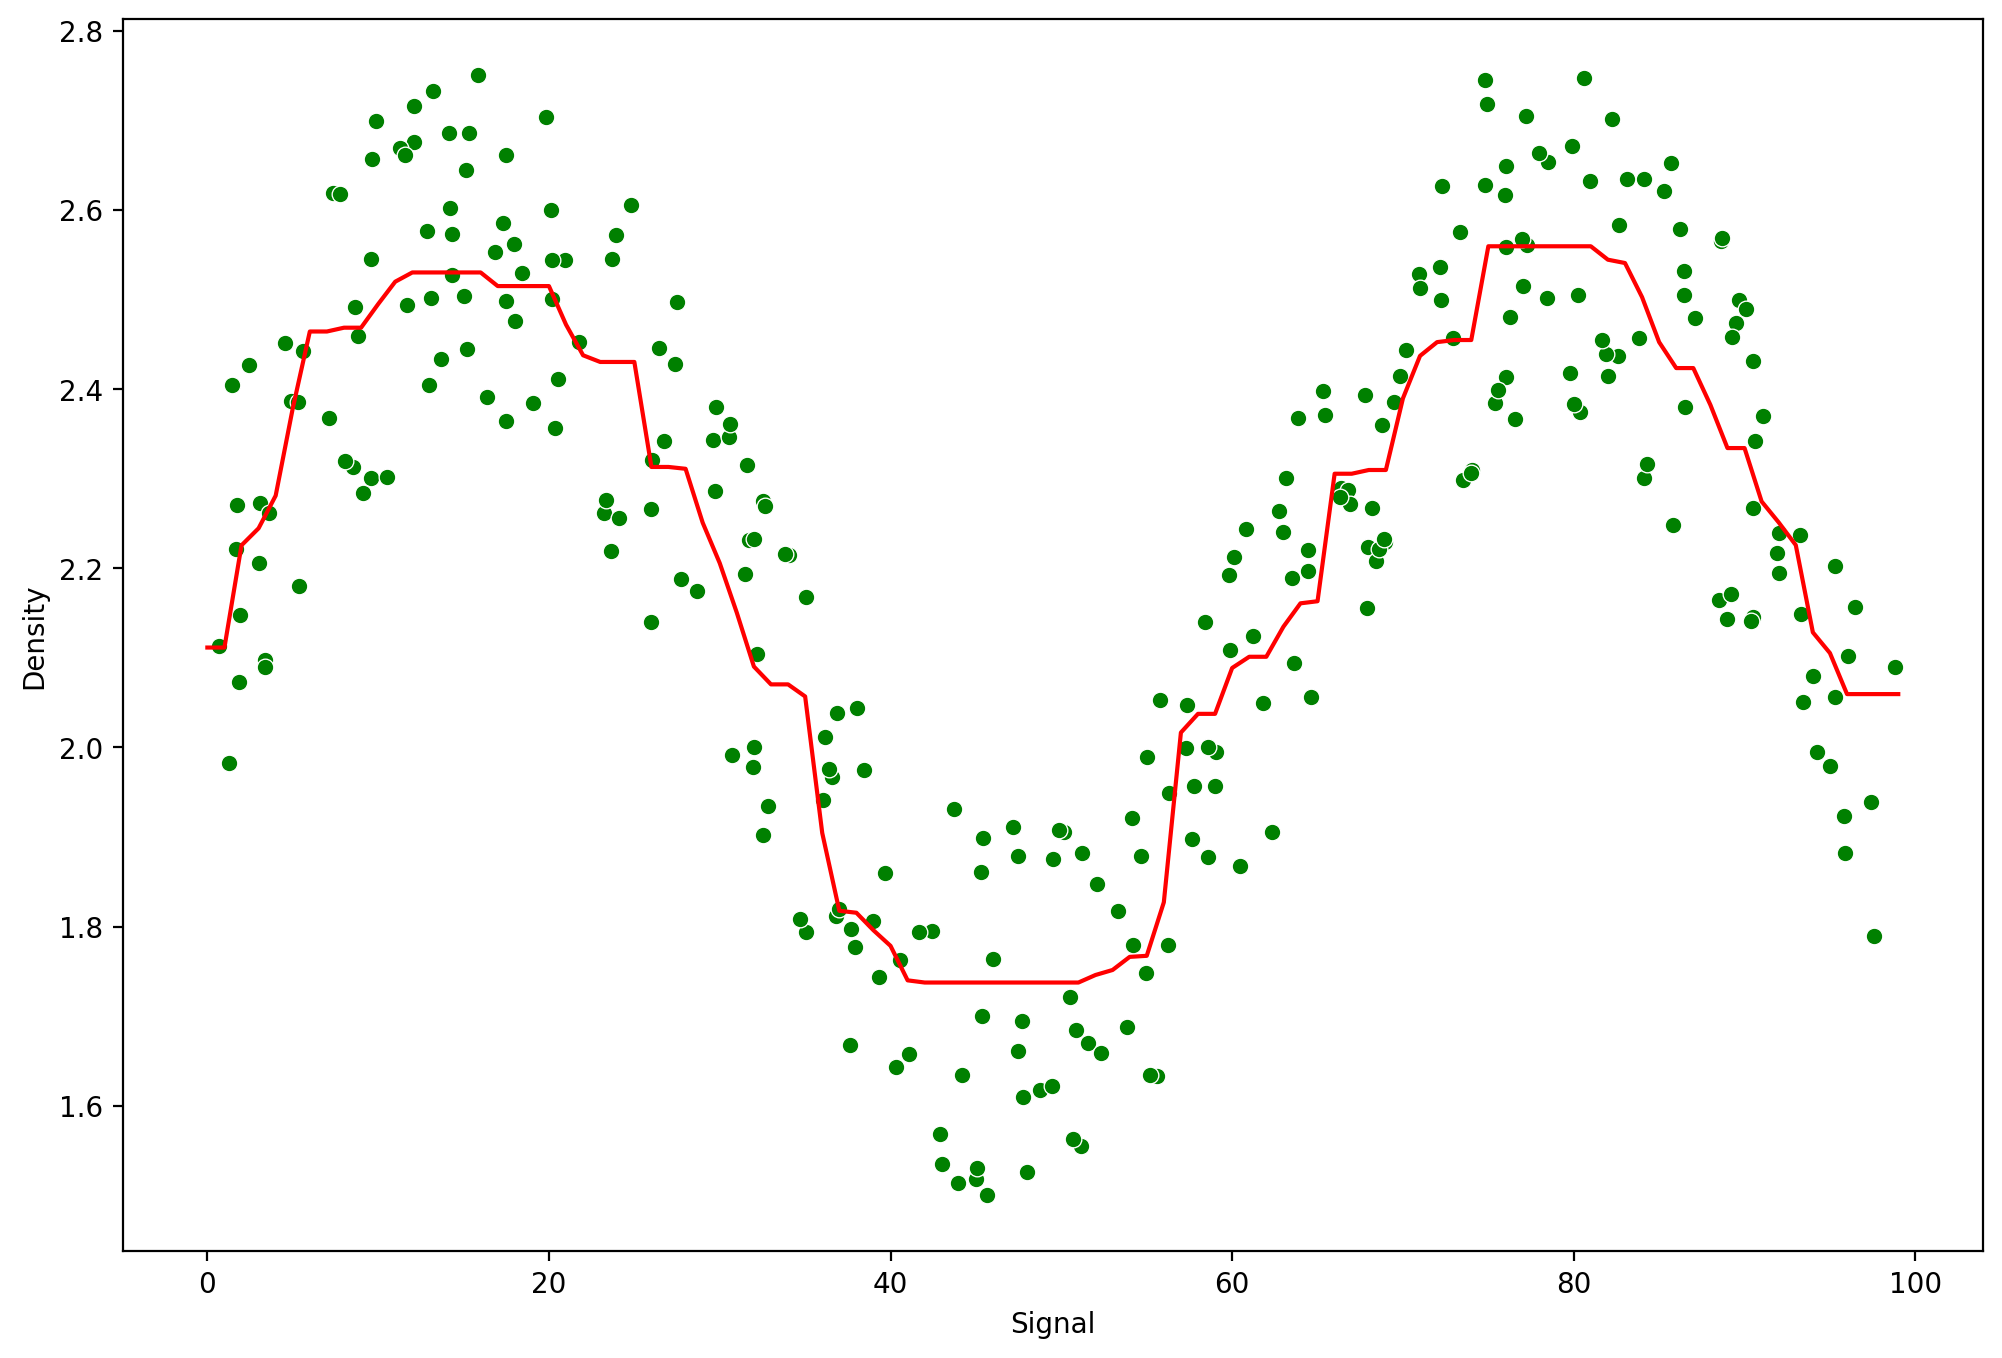

In [93]:
model = AdaBoostRegressor()
run_model(model, X_train, y_train, X_test, y_test)